# **Chapter 2. DFT-Based Harmonic Representations and Their Integration with Voice-Leading**

## Settings & Imports

In [1]:
!git clone https://github.com/elisavetaslav/ITG-JS-persistent-homology.git
%cd ./ITG-JS-persistent-homology
!pip install -r requirements.txt

Cloning into 'ITG-JS-persistent-homology'...
remote: Enumerating objects: 307, done.
remote: Counting objects: 100% (307/307), done.
remote: Compressing objects: 100% (268/268), done.
remote: Total 307 (delta 61), reused 281 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (307/307), 38.81 MiB | 18.69 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/ITG-JS-persistent-homology
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 53.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.append(str(ROOT))

from visualization.plotting import setup_notebook_plots
setup_notebook_plots()

In [47]:
from features.ch2_preprocessing import build_lookup, build_event_cache
from analysis.ch2_diagnostics import audit_dataset, compute_chord_burden
from features.ch2_harmonic import (
    build_harmonic_cloud,
    harmonic_feature_vector_from_events,
)
from features.ch2_feature_tables import (
    build_harmonic_feature_table,
    build_voice_feature_table,
    build_fusion_feature_table
)
from analysis.ch2_evaluation import evaluate_branch
from visualization.pca_dispersion import plot_pca_and_dispersion
from features.ch2_voice_leading import get_interval_state_count
from visualization.ch2_plots import (
    plot_fusion_barcodes_for_piece,
    plot_model_metric_comparison,
    plot_harmonic_barcodes_for_piece,
    plot_voice_barcodes_for_piece
)

## Datasets

The experiments in this notebook use two custom datasets of string quartet movements by Joseph Haydn, Wolfgang Amadeus Mozart, and Ludwig van Beethoven.  
The small dataset contains the focused subset corresponding to the examples listed in the original study by Mijangos et al., while the large dataset follows the broader catalogue structure used in the main experiments.  

Each work is described by a metadata table with the fields  
`filename`, `composer`, `genre`, `opus`, `key`, `movement`, and `date`.

In the present notebook, the small dataset is used for step-by-step illustration of the preprocessing pipeline.

In [5]:
DATA_SMALL = ROOT / "data" / "raw" / "classic_music_small"
DATA_BIG = ROOT / "data" / "raw" / "classic_music_big"
METADATA_SMALL = ROOT / "data" / "metadata" / "metadata_small.csv"
METADATA_BIG = ROOT / "data" / "metadata" / "metadata_big.csv"

df_small = pd.read_csv(METADATA_SMALL)
print(f"Total files in the small dataset: {len(df_small)}")
df_small.sample(10)

Total files in the small dataset: 18


,filename,composer,genre,opus,key,movement,date
10,k387-02.mid,Mozart,Menuetto,No.14,G major,2,1782
15,quartet06-3.mid,Beethoven,Scherzo: Allegro,Op.18/6,Bb major,3,1798
12,k590-03.mid,Mozart,Menuetto-Allegretto,No.23,F major,3,1790
7,k158-03.mid,Mozart,Tempo di Minuetto,No.5,F major,3,1773
11,k465-03.mid,Mozart,Menuetto,No.19,C major,3,1785
13,quartet01-3.mid,Beethoven,Scherzo: Allegro molto,Op.18/1,F major,3,1798
2,op33n3-02.mid,Haydn,Scherzando,Op.33/3,C major,2,1781
17,quartet12-3.mid,Beethoven,Scherzando vivace - Presto,Op.127,Eb major,3,1825
3,op50n3-03.mid,Haydn,Menuetto,Op.50/3,Eb major,3,1787
14,quartet04-3.mid,Beethoven,Menuetto: Allegretto,Op.18/4,C major,3,1798


In [58]:
df_big = pd.read_csv(METADATA_BIG)
print(f"Total files in the big dataset: {len(df_big)}")
df_big.sample(10)

Total files in the big dataset: 140


,filename,composer,genre,opus,key,movement,date
1,quartet05-2.mid,Beethoven,Minuet,Op.18/5,A major,2,1798-1800
125,op17n5-04.mid,Haydn,Presto,Op.17/5,G major,4,1771
92,op71n1-01.mid,Haydn,Allegro,Op.71/1,Bb major,1,1793
124,op17n1-04.mid,Haydn,Presto,Op.17/1,E major,4,1771
96,op01n4-02.mid,Haydn,Minuet,Op.01/4,G major,2,NaN
56,k171-02.mid,Mozart,Minuet,No.11,Eb major,2,1773
95,op01n3-04.mid,Haydn,Minuet,Op.01/3,D major,4,NaN
82,op01n2-01.mid,Haydn,Allegro,Op.01/2,Eb major,1,NaN
133,op55n3-04.mid,Haydn,Presto,Op.55/3,Bb major,4,1788
13,quartet08-1.mid,Beethoven,Allegro,Op.59/2,E minor,1,1806


## Dataset Filtration & Preproccessing

In [9]:
small_lookup = build_lookup(DATA_SMALL, ext='mid')
big_lookup = build_lookup(DATA_BIG, ext='mid')

df_small['filepath'] = df_small['filename'].map(small_lookup)
df_big['filepath'] = df_big['filename'].map(big_lookup)

print("SMALL found:", df_small['filepath'].notna().sum(), "/", len(df_small))
print("BIG   found:", df_big['filepath'].notna().sum(), "/", len(df_big))

SMALL found: 18 / 18
BIG   found: 140 / 140


In [10]:
CHORD_SHARE_THRESHOLD = 0.05
QUANT_STEP = 0.125
MIN_EVENT_DUR = 0.125

In [13]:
# audit
df_audit_small = audit_dataset(df_small, quant_step=QUANT_STEP, min_event_dur=MIN_EVENT_DUR)
df_audit_big = audit_dataset(df_big, quant_step=QUANT_STEP, min_event_dur=MIN_EVENT_DUR)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

In [14]:
# chord burden
df_burden_small = compute_chord_burden(df_audit_small)
df_burden_big = compute_chord_burden(df_audit_big)

In [15]:
# main filter
df_burden_small["main_ok"] = (
    df_burden_small["eligible_core"]
    & (df_audit_small["n_parts"] == 4)
    & (df_burden_small["chord_share"] <= CHORD_SHARE_THRESHOLD)
)

df_burden_big["main_ok"] = (
    df_burden_big["eligible_core"]
    & (df_audit_big["n_parts"] == 4)
    & (df_burden_big["chord_share"] <= CHORD_SHARE_THRESHOLD)
)

print("SMALL main_ok:", int(df_burden_small["main_ok"].sum()), "/", len(df_burden_small))
print("BIG   main_ok:", int(df_burden_big["main_ok"].sum()), "/", len(df_burden_big))

SMALL main_ok: 18 / 18
BIG   main_ok: 108 / 140


In [16]:
df_small_full = (df_small.merge(
        df_audit_small[["filename", "parse_ok", "n_parts", "n_vertical_events",
                        "part_note_counts", "part_chord_counts", "part_max_chord_size",
                        "eligible_core", "eligible_strict_vl", "problems", "warnings"]],
        on="filename",
        how="left"
    ).merge(
        df_burden_small[["filename", "total_notes", "total_chords", "total_note_like",
                         "chord_share", "max_chord_size", "main_ok"]],
        on="filename",
        how="left"
))

df_big_full = (df_big.merge(
        df_audit_big[[
            "filename", "parse_ok", "n_parts", "n_vertical_events",
            "part_note_counts", "part_chord_counts", "part_max_chord_size",
            "eligible_core", "eligible_strict_vl", "problems", "warnings"]],
        on="filename",
        how="left"
    ).merge(
        df_burden_big[[
            "filename", "total_notes", "total_chords", "total_note_like",
            "chord_share", "max_chord_size", "main_ok"]],
        on="filename",
        how="left"
))

df_small_main = df_small_full[df_small_full["main_ok"] == True].copy().reset_index(drop=True)
df_big_main = df_big_full[df_big_full["main_ok"] == True].copy().reset_index(drop=True)

print("SMALL main dataset:", len(df_small_main))
print("BIG   main dataset:", len(df_big_main))

SMALL main dataset: 18
BIG   main dataset: 108


In [18]:
event_cache_small, failed_small = build_event_cache(
    df_small_main,
    quant_step=QUANT_STEP,
    min_event_dur=MIN_EVENT_DUR
)

event_cache_big, failed_big = build_event_cache(
    df_big_main,
    quant_step=QUANT_STEP,
    min_event_dur=MIN_EVENT_DUR
)

print("event_cache_small:", len(event_cache_small), "failed:", len(failed_small))
print("event_cache_big:", len(event_cache_big), "failed:", len(failed_big))

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/108 [00:00<?, ?it/s]

event_cache_small: 18 failed: 0
event_cache_big: 108 failed: 0


In [19]:
def print_preprocessing_summary(df_pre, name="dataset"):
    print("=" * 100)
    print(name)
    print("=" * 100)
    print("Total files:", len(df_pre))
    print("parse_ok:", int(df_pre["parse_ok"].fillna(False).sum()))
    print("eligible_core:", int(df_pre["eligible_core"].fillna(False).sum()))
    print("eligible_strict_vl:", int(df_pre["eligible_strict_vl"].fillna(False).sum()))
    print("main_ok:", int(df_pre["main_ok"].fillna(False).sum()))
    print()
    print("n_parts counts:")
    print(df_pre["n_parts"].value_counts(dropna=False).sort_index())
    print()
    print("chord_share summary:")
    print(df_pre["chord_share"].describe())
    print()
    print("n_vertical_events summary:")
    print(df_pre["n_vertical_events"].describe())

print_preprocessing_summary(df_small_full, "SMALL PREPROCESSING SUMMARY")
print_preprocessing_summary(df_big_full, "BIG PREPROCESSING SUMMARY")

SMALL PREPROCESSING SUMMARY
Total files: 18
parse_ok: 18
eligible_core: 18
eligible_strict_vl: 4
main_ok: 18

n_parts counts:
n_parts
4    18
Name: count, dtype: int64

chord_share summary:
count    18.000000
mean      0.012300
std       0.013448
min       0.000000
25%       0.003343
50%       0.008240
75%       0.014563
max       0.039698
Name: chord_share, dtype: float64

n_vertical_events summary:
count      18.000000
mean      740.277778
std       701.438757
min       161.000000
25%       288.500000
50%       527.000000
75%       971.000000
max      2975.000000
Name: n_vertical_events, dtype: float64
BIG PREPROCESSING SUMMARY
Total files: 140
parse_ok: 140
eligible_core: 138
eligible_strict_vl: 14
main_ok: 108

n_parts counts:
n_parts
4    138
5      2
Name: count, dtype: int64

chord_share summary:
count    140.000000
mean       0.038942
std        0.061139
min        0.000000
25%        0.005519
50%        0.016616
75%        0.041493
max        0.427315
Name: chord_share, dtype:

In [21]:
TABLES_DIR = ROOT / "tables"
TABLES_DIR.mkdir(exist_ok=True)

df_small_full.to_csv('./tables/df_small_preprocessed_ch2.csv', index=False)
df_big_full.to_csv('./tables/df_big_preprocessed_ch2.csv', index=False)

df_small_main.to_csv('./tables/df_small_main_ch2.csv', index=False)
df_big_main.to_csv('./tables/df_big_main_ch2.csv', index=False)

print("Saved:")
print("./tables/df_small_preprocessed_ch2.csv")
print("./tables/df_big_preprocessed_ch2.csv")
print("./tables/df_small_main_ch2.csv")
print("./tables/df_big_main_ch2.csv")

Saved:
./tables/df_small_preprocessed_ch2.csv
./tables/df_big_preprocessed_ch2.csv
./tables/df_small_main_ch2.csv
./tables/df_big_main_ch2.csv


In [22]:
df_small_raw = df_small.copy()
df_big_raw = df_big.copy()

df_small = df_small_main.copy()
df_big = df_big_main.copy()

## **Harmonic model**

### Harmonic descriptors and persistence

In [24]:
sample_filename = df_small_main.iloc[0]["filename"]
sample_filepath = df_small_main.iloc[0]["filepath"]
sample_events = event_cache_small[sample_filename]

sample_cloud, sample_n_bars = build_harmonic_cloud(
    sample_filepath,
    sample_events,
    quant_step=QUANT_STEP,
    unique_only=True,
    round_decimals=8
)

sample_feat = harmonic_feature_vector_from_events(
    sample_filepath,
    sample_events,
    quant_step=QUANT_STEP,
    unique_only=True,
    round_decimals=8,
    maxdim=1,
    prefix="HARM_"
)

print("Sample filename:", sample_filename)
print("Number of vertical events:", len(sample_events))
print("Number of bars:", sample_n_bars)
print("Harmonic cloud shape:", sample_cloud.shape)
print("First five harmonic descriptors:")
print(sample_cloud[:5])

print("\nSample feature vector:")
for key, value in sample_feat.items():
    print(f"{key}: {value}")

Sample filename: op17n2-02.mid
Number of vertical events: 179
Number of bars: 62
Harmonic cloud shape: (48, 6)
First five harmonic descriptors:
[[0.         0.         0.         1.         0.         0.        ]
 [0.01836748 0.36825204 0.59056366 0.27743034 0.50158912 0.11111111]
 [0.05345966 0.14433757 0.26352314 0.62915287 0.46836341 0.5       ]
 [0.05751534 0.11111111 0.248452   0.83887049 0.21465018 0.11111111]
 [0.05863982 0.20459611 0.35409858 0.53737617 0.54294261 0.36111111]]

Sample feature vector:
HARM_H0_mean: 0.23810902919541013
HARM_H0_std: 0.0747958059044677
HARM_H0_entropy: 3.723380528573813
HARM_H1_mean: 0.023307037624445828
HARM_H1_std: 0.01572713046412499
HARM_H1_entropy: 2.187232738591998
HARM_n_bars: 62.0
HARM_n_points: 48.0


### Harmonic feature tables

In [25]:
df_small_harm = build_harmonic_feature_table(
    df_small_main,
    event_cache_small,
    quant_step=QUANT_STEP,
    unique_only=True,
    round_decimals=8,
    maxdim=1,
    prefix="HARM_"
)

df_big_harm = build_harmonic_feature_table(
    df_big_main,
    event_cache_big,
    quant_step=QUANT_STEP,
    unique_only=True,
    round_decimals=8,
    maxdim=1,
    prefix="HARM_"
)

print("SMALL harmonic table shape:", df_small_harm.shape)
print("BIG harmonic table shape:", df_big_harm.shape)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/108 [00:00<?, ?it/s]

SMALL harmonic table shape: (18, 32)
BIG harmonic table shape: (108, 32)


In [26]:
all_harm_cols  = [c for c in df_small_harm.columns if c.startswith("HARM_")]

print("Number of harmonic feature columns:", len(all_harm_cols))

display(df_small_harm[["filename", "composer", "genre"] + all_harm_cols].head())
display(df_big_harm[["filename", "composer", "genre"] + all_harm_cols].head())

Number of harmonic feature columns: 8


,filename,composer,genre,HARM_H0_mean,HARM_H0_std,HARM_H0_entropy,HARM_H1_mean,HARM_H1_std,HARM_H1_entropy,HARM_n_bars,HARM_n_points
0,op17n2-02.mid,Haydn,Menuetto,0.238109,0.074796,3.723381,0.023307,0.015727,2.187233,62.0,48.0
1,op20n1-02.mid,Haydn,Menuetto,0.241702,0.083593,3.690068,0.034908,0.034267,2.549817,65.0,47.0
2,op33n3-02.mid,Haydn,Scherzando,0.300721,0.151941,3.263624,0.025181,0.019862,2.030496,50.0,33.0
3,op50n3-03.mid,Haydn,Menuetto,0.241802,0.107565,3.921587,0.026721,0.021119,2.922082,85.0,60.0
4,op64n1-02.mid,Haydn,Menuetto,0.197727,0.089912,5.111954,0.031553,0.025713,4.124967,260.0,191.0


,filename,composer,genre,HARM_H0_mean,HARM_H0_std,HARM_H0_entropy,HARM_H1_mean,HARM_H1_std,HARM_H1_entropy,HARM_n_bars,HARM_n_points
0,quartet04-3.mid,Beethoven,Minuet,0.253277,0.117582,4.136083,0.023408,0.019637,3.207789,218.0,75.0
1,quartet05-2.mid,Beethoven,Minuet,0.236085,0.081344,4.294391,0.025318,0.019779,3.455177,267.0,83.0
2,quartet09-3.mid,Beethoven,Minuet,0.205765,0.098491,4.183144,0.025209,0.016452,3.146340,190.0,80.0
3,quartet01-3.mid,Beethoven,Scherzo,0.215470,0.088433,4.460277,0.023398,0.019553,3.203310,331.0,100.0
4,quartet02-3.mid,Beethoven,Scherzo,0.216726,0.102579,4.266480,0.017997,0.015448,3.269559,217.0,85.0


### Harmonic-only evaluation

In [27]:
HARM_CORE_COLS = ["HARM_H0_mean", "HARM_H0_std", "HARM_H0_entropy",
                  "HARM_H1_mean", "HARM_H1_std", "HARM_H1_entropy"]
HARM_AUX_COLS = ["HARM_n_bars", "HARM_n_points"]
harm_cols = HARM_CORE_COLS

print("Number of harmonic core features:", len(HARM_CORE_COLS))
print("Number of harmonic auxiliary features:", len(HARM_AUX_COLS))

Number of harmonic core features: 6
Number of harmonic auxiliary features: 2


In [28]:
df_small_harm_summary, df_small_harm_dispersion, df_small_harm_centroids, df_small_harm_pca_disp, X_small_harm, Z_small_harm, y_small_harm, pca_small_harm = evaluate_branch(
    df_small_harm,
    harm_cols,
    label_col="composer",
    dataset_name="SMALL",
    model_name="Harmonic-only"
)

df_big_harm_summary, df_big_harm_dispersion, df_big_harm_centroids, df_big_harm_pca_disp, X_big_harm, Z_big_harm, y_big_harm, pca_big_harm = evaluate_branch(
    df_big_harm,
    harm_cols,
    label_col="composer",
    dataset_name="BIG",
    model_name="Harmonic-only"
)

df_harmonic_eval_summary = pd.concat(
    [df_small_harm_summary, df_big_harm_summary],
    ignore_index=True
)

display(df_harmonic_eval_summary)

,dataset,model,label_col,n_samples,n_features,pc1_variance,pc2_variance,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,max_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,SMALL,Harmonic-only,composer,18,6,0.556041,0.263838,0.819879,-0.016314,-0.067480,3.180944,2.416113,2.629445,1.263105,1.682795,2.234020,0.444444,0.555556
1,BIG,Harmonic-only,composer,108,6,0.500170,0.286712,0.786882,-0.053321,-0.077835,7.646570,2.307071,2.633998,0.453710,1.218713,1.638626,0.546296,0.425926


In [29]:
print("SMALL within-class dispersion")
display(df_small_harm_dispersion)

print("SMALL centroid distances")
display(df_small_harm_centroids)

print("SMALL PCA-space dispersion")
display(df_small_harm_pca_disp)

print("BIG within-class dispersion")
display(df_big_harm_dispersion)

print("BIG centroid distances")
display(df_big_harm_centroids)

print("BIG PCA-space dispersion")
display(df_big_harm_pca_disp)

SMALL within-class dispersion


,label,n_samples,mean_distance,median_distance,max_distance,rms_distance
0,Haydn,7,2.227780,2.299117,3.722924,2.629445
1,Mozart,6,2.203887,2.235639,3.453520,2.567835
2,Beethoven,5,1.690291,1.315778,2.843230,2.051057


SMALL centroid distances


,Haydn,Mozart,Beethoven
Haydn,0.000000,1.263105,1.55126
Mozart,1.263105,0.000000,2.23402
Beethoven,1.551260,2.234020,0.00000


SMALL PCA-space dispersion


...

,label,n_samples,mean_distance,median_distance,max_distance,rms_distance
0,Haydn,62,2.193406,1.976526,5.453062,2.399003
1,Mozart,32,2.417594,2.219377,4.716780,2.633998
2,Beethoven,14,1.670117,1.641865,3.151833,1.888210


BIG centroid distances


,Haydn,Mozart,Beethoven
Haydn,0.000000,0.453710,1.638626
Mozart,0.453710,0.000000,1.563803
Beethoven,1.638626,1.563803,0.000000


BIG PCA-space dispersion


,label,n_samples,pca_dispersion
0,Haydn,62,2.134223
1,Mozart,32,2.323423
2,Beethoven,14,1.717253


PCA and dispersion plots

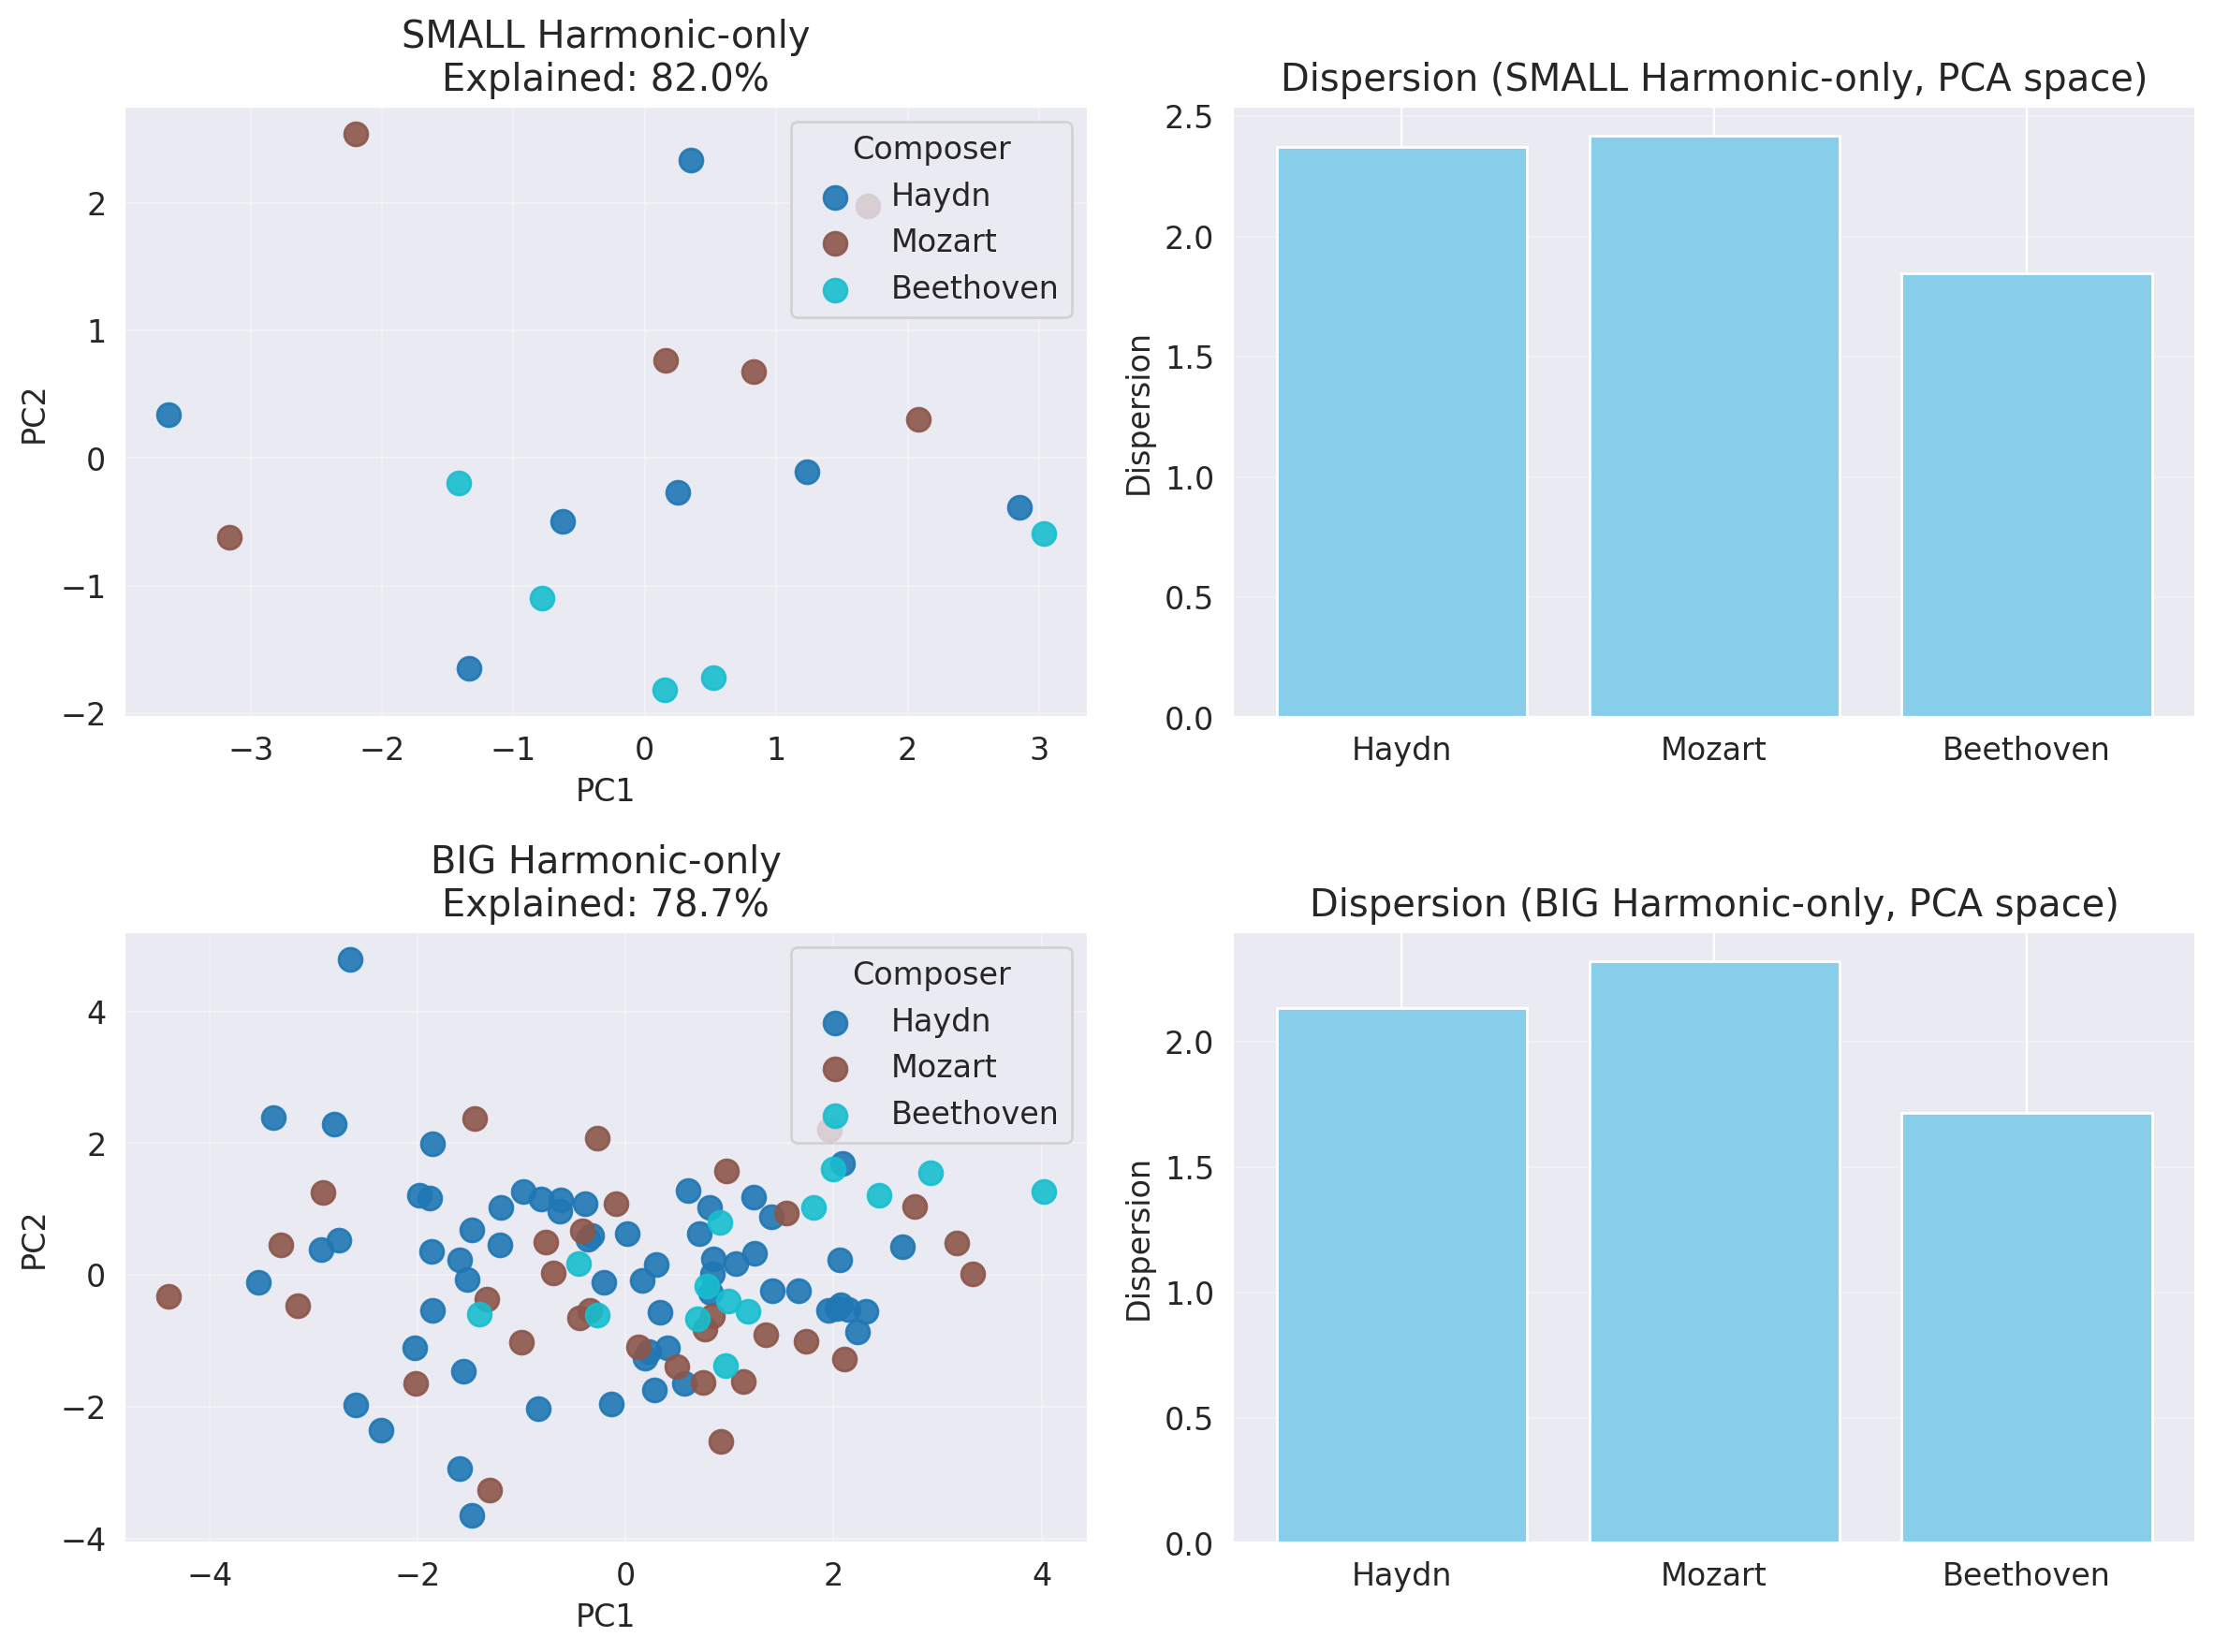

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

plot_pca_and_dispersion(X_small_harm, "SMALL Harmonic-only", axes[0, 0], axes[0, 1], y_small_harm, scale=False)
plot_pca_and_dispersion(X_big_harm, "BIG Harmonic-only", axes[1, 0], axes[1, 1], y_big_harm, scale=False)

plt.tight_layout()
plt.show()

,composer,filename,filepath
0,Beethoven,quartet01-3.mid,/content/ITG-JS-persistent-homology/data/raw/c...
1,Haydn,op17n2-02.mid,/content/ITG-JS-persistent-homology/data/raw/c...
2,Mozart,k158-03.mid,/content/ITG-JS-persistent-homology/data/raw/c...


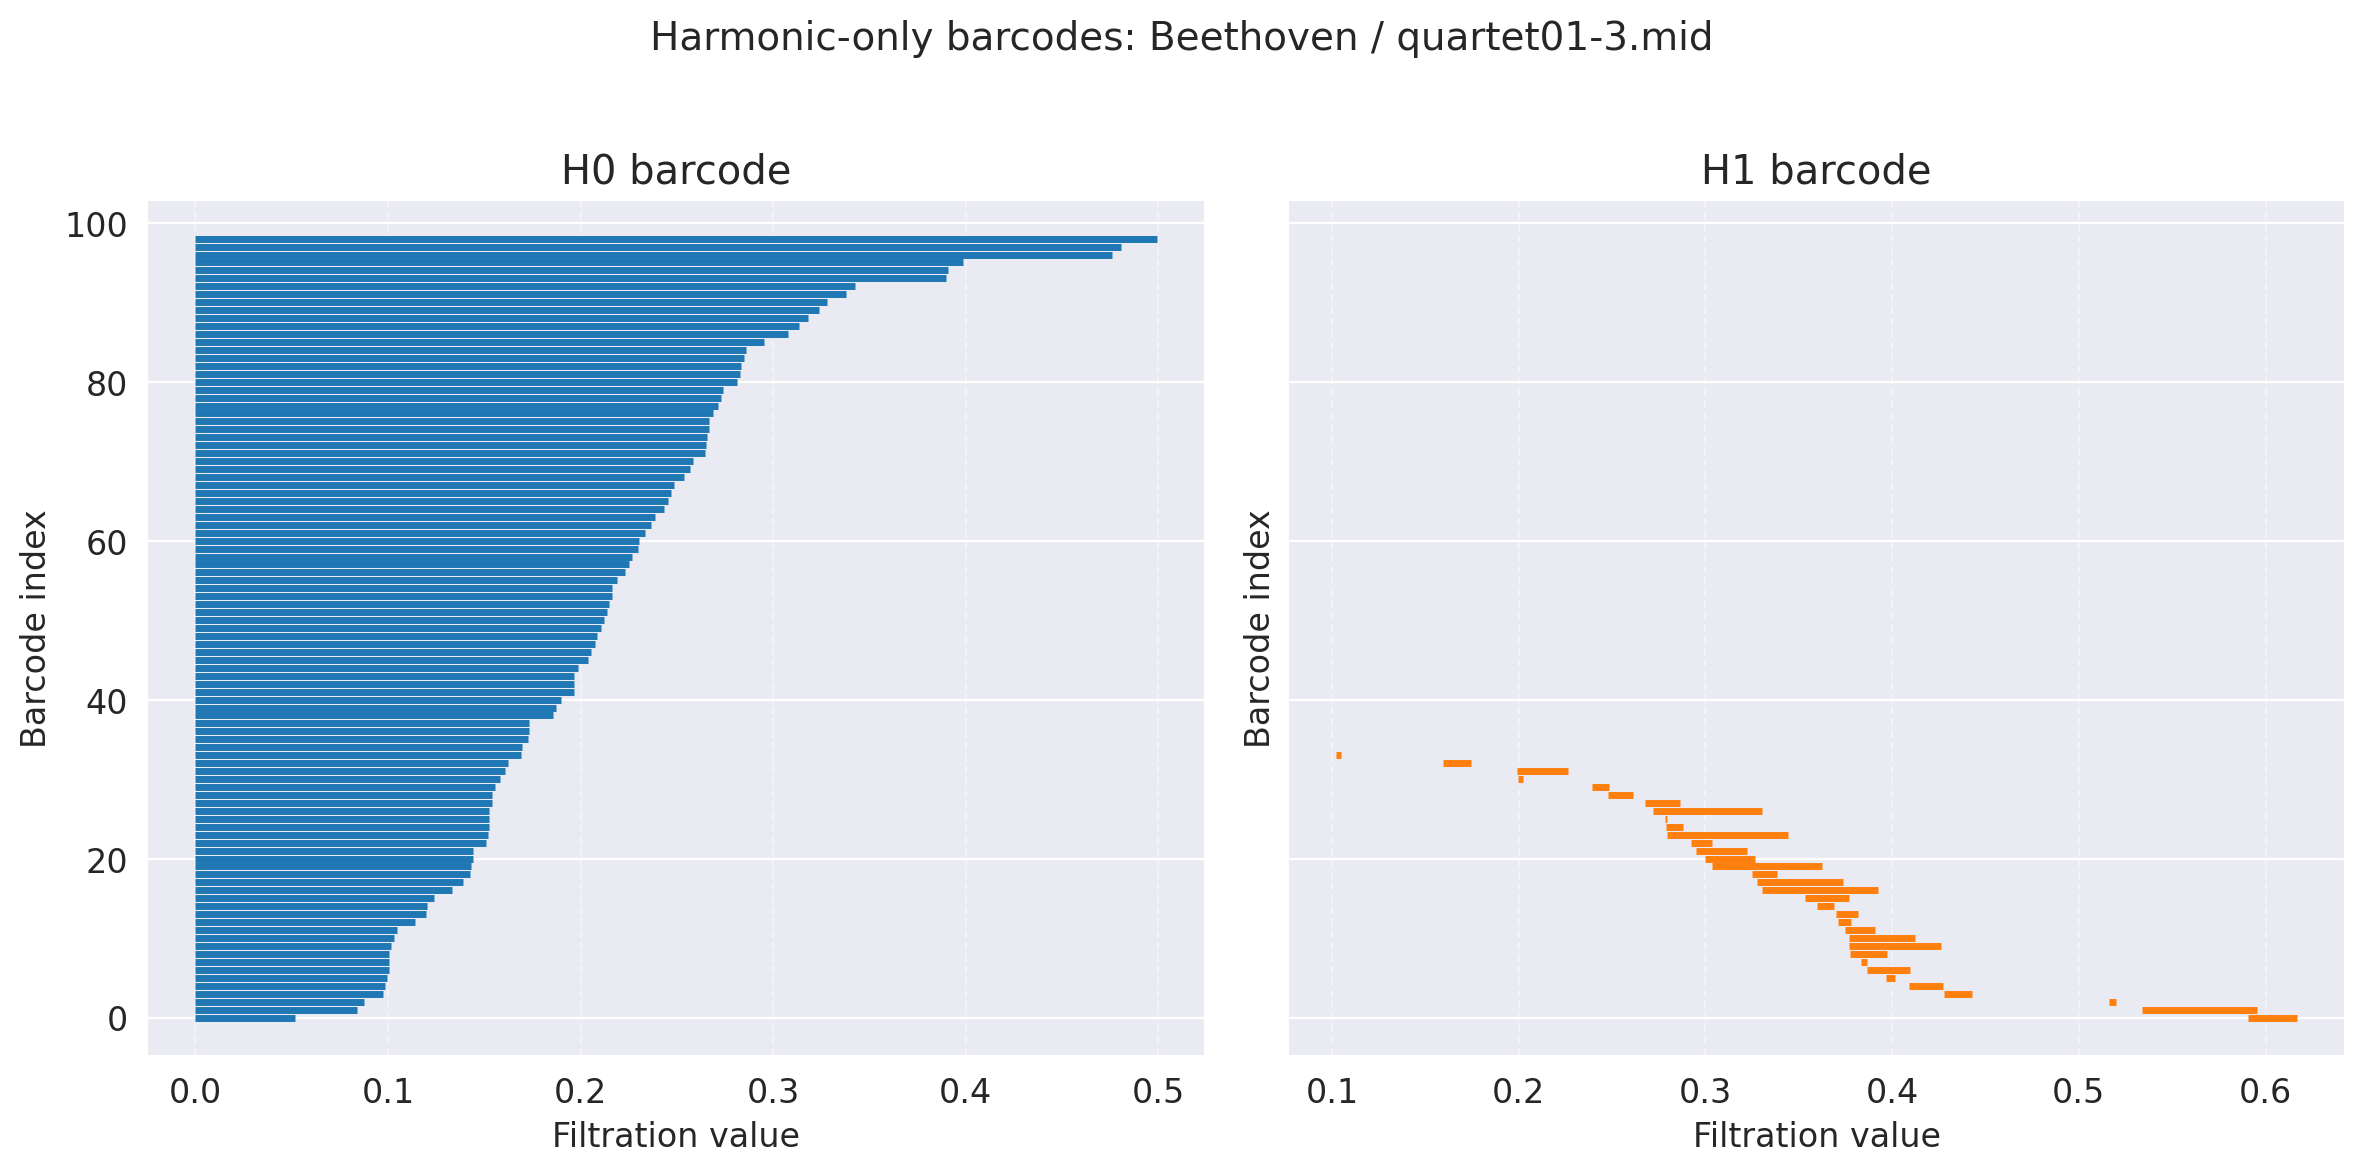

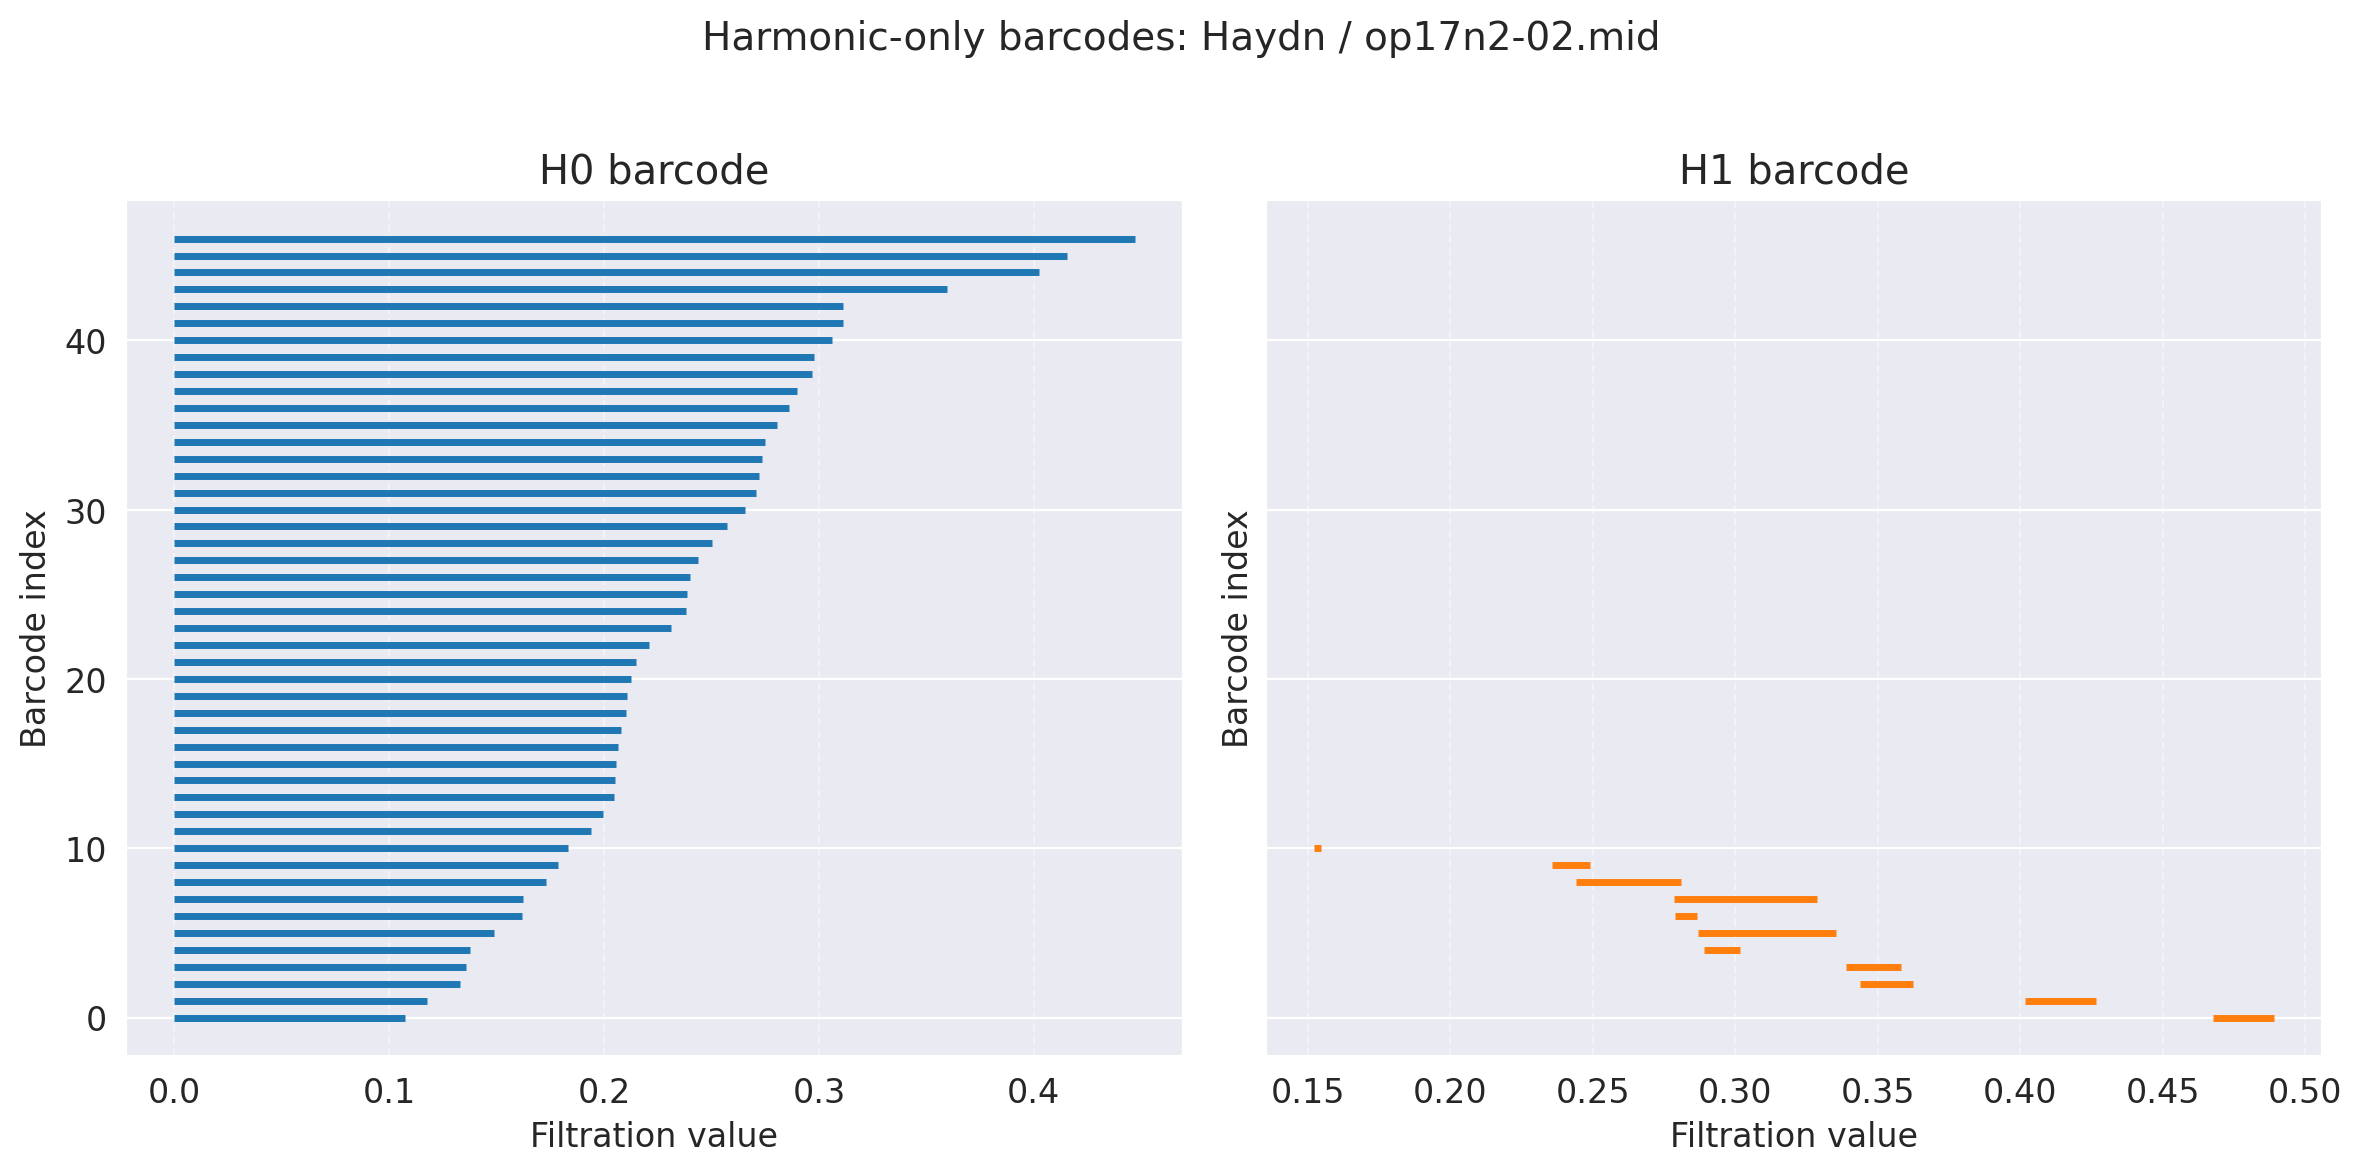

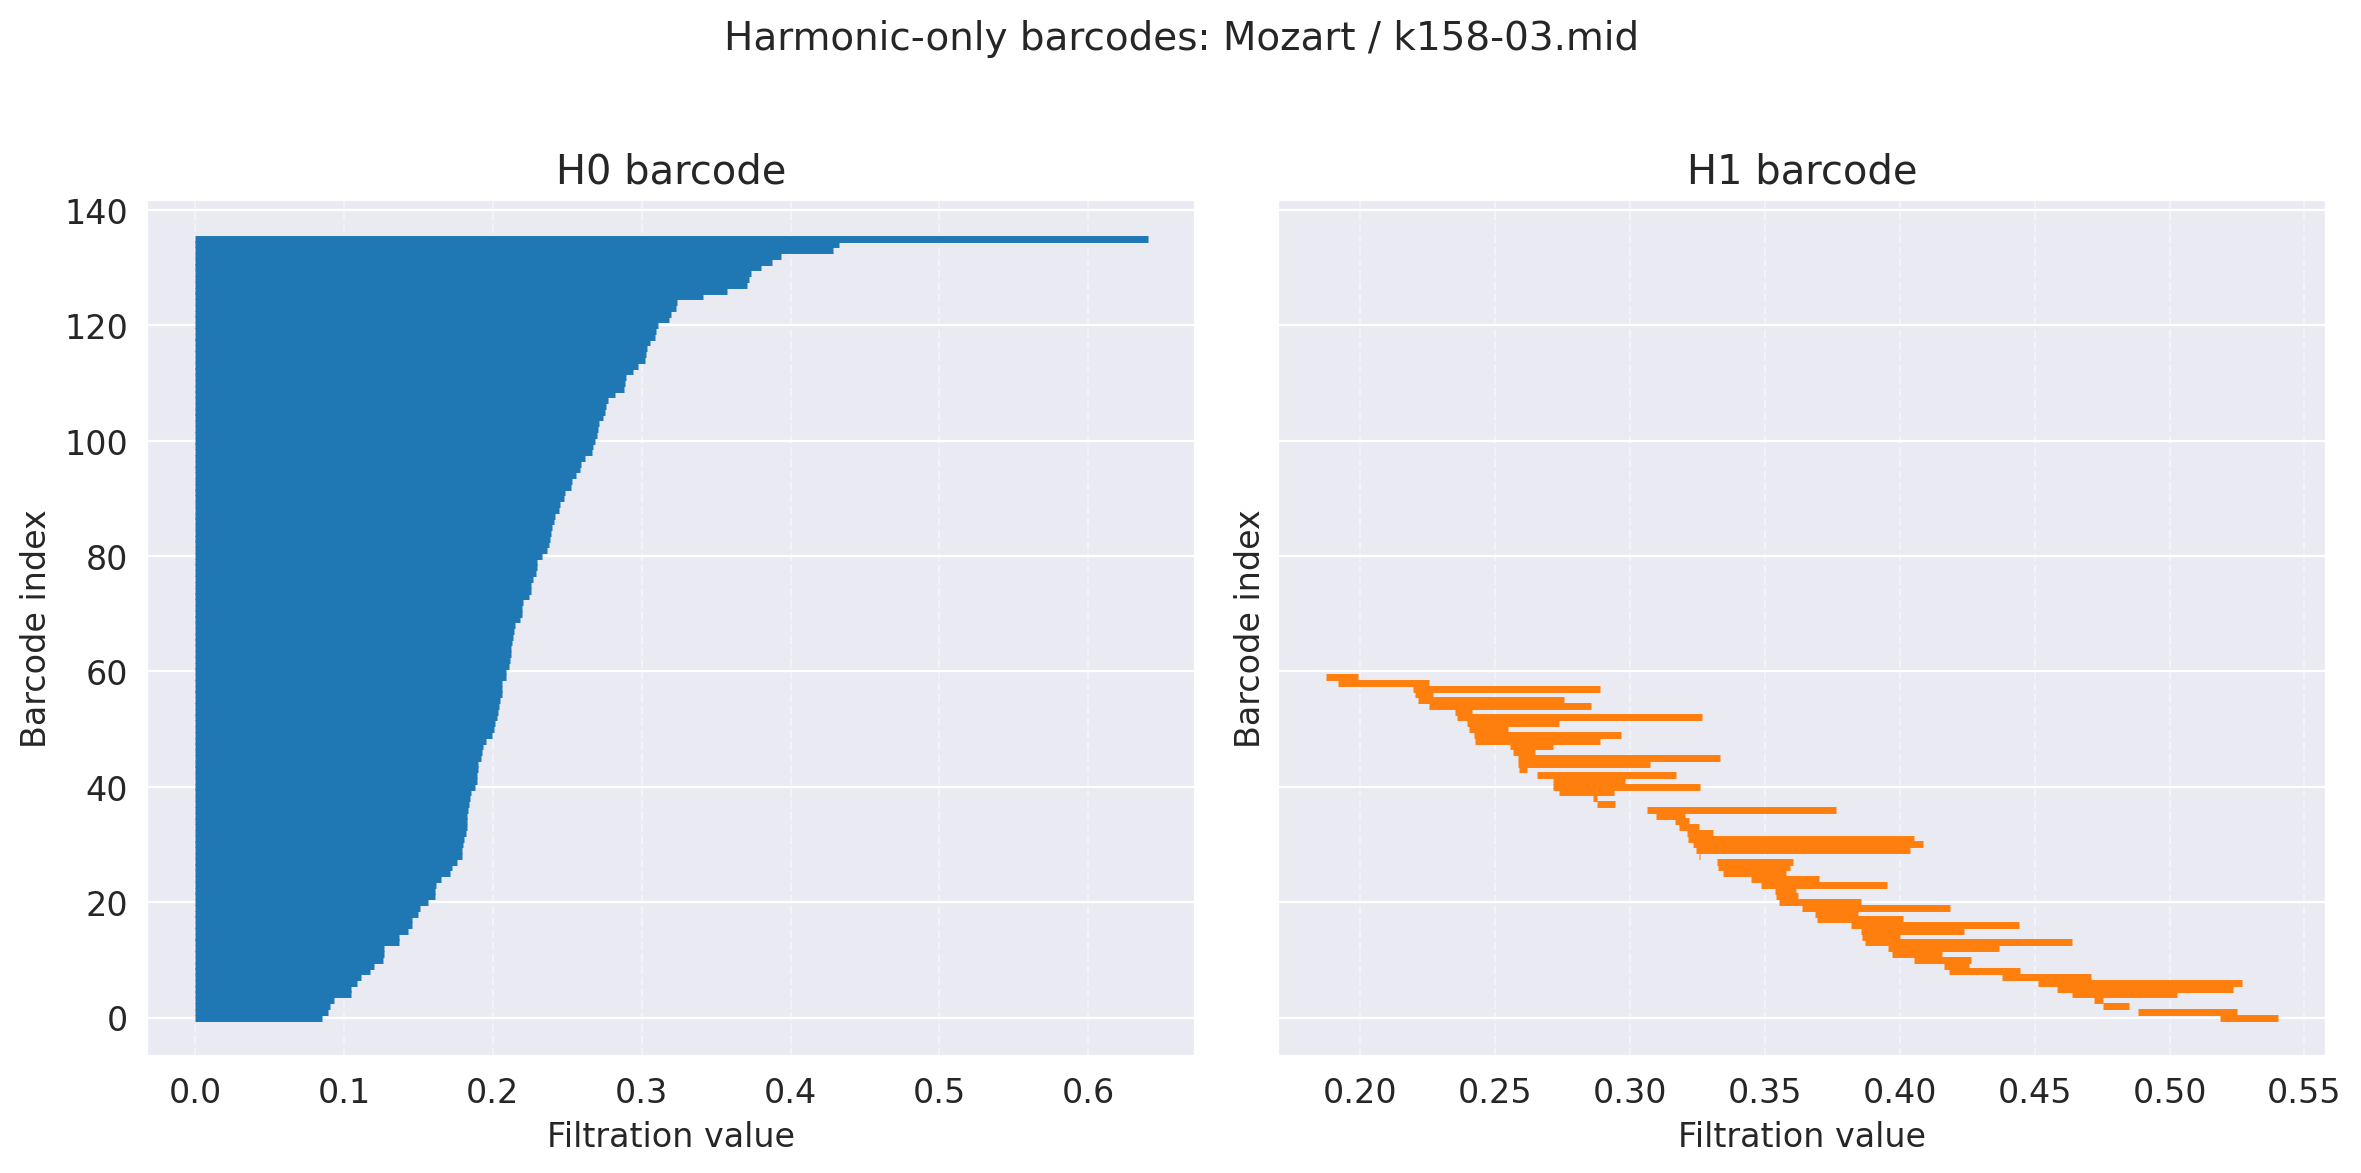

In [35]:
small_examples = (
    df_small_harm.groupby("composer", as_index=False)
    .first()[["composer", "filename", "filepath"]]
)

display(small_examples)

for _, row in small_examples.iterrows():
    plot_harmonic_barcodes_for_piece(
        row["filepath"],
        row["filename"],
        event_cache_small,
        quant_step=QUANT_STEP,
        title=f"Harmonic-only barcodes: {row['composer']} / {row['filename']}",
        unique_only=True,
        round_decimals=8,
        maxdim=1
    )

In [36]:
df_harmonic_eval_summary.to_csv("./tables/harmonic_eval_summary.csv", index=False)
df_small_harm_dispersion.to_csv("./tables/harmonic_small_dispersion.csv", index=False)
df_big_harm_dispersion.to_csv("./tables/harmonic_big_dispersion.csv", index=False)
df_small_harm_centroids.to_csv("./tables/harmonic_small_centroid_distances.csv")
df_big_harm_centroids.to_csv("./tables/harmonic_big_centroid_distances.csv")
df_small_harm_pca_disp.to_csv("./tables/harmonic_small_pca_dispersion.csv", index=False)
df_big_harm_pca_disp.to_csv("./tables/harmonic_big_pca_dispersion.csv", index=False)

print("Saved:")
print("./tables/harmonic_eval_summary.csv")
print("./tables/harmonic_small_dispersion.csv")
print("./tables/harmonic_big_dispersion.csv")
print("./tables/harmonic_small_centroid_distances.csv")
print("./tables/harmonic_big_centroid_distances.csv")
print("./tables/harmonic_small_pca_dispersion.csv")
print("./tables/harmonic_big_pca_dispersion.csv")

Saved:
./tables/harmonic_eval_summary.csv
./tables/harmonic_small_dispersion.csv
./tables/harmonic_big_dispersion.csv
./tables/harmonic_small_centroid_distances.csv
./tables/harmonic_big_centroid_distances.csv
./tables/harmonic_small_pca_dispersion.csv
./tables/harmonic_big_pca_dispersion.csv


The harmonic-only branch already provides a meaningful but limited stylistic signal. In both datasets, the first two principal components explain a substantial share of the variance in the harmonic topological features: \(0.8199\) on the small dataset and \(0.7869\) on the large dataset. This suggests that the harmonic feature space has a fairly clear low-dimensional structure. At the same time, the class-separation metrics show that harmonic information alone is not sufficient for clean composer separation. Both datasets have negative silhouette scores: \(-0.0163\) and \(-0.0675\) on the small dataset, and \(-0.0533\) and \(-0.0778\) on the large dataset for the full and PCA spaces, respectively. The Davies-Bouldin index is also relatively high, especially on the large dataset, where it reaches \(7.6466\). Thus, the harmonic-only representation captures structure, but the composer clouds still overlap substantially.

A more detailed look at the class geometry shows that the clearest contrast is between Beethoven and the Haydn-Mozart pair. In both datasets, the Haydn-Mozart centroid distance is the smallest one: \(1.2631\) on the small dataset and \(0.4537\) on the large dataset. By contrast, Beethoven is farther from both Haydn and Mozart, especially in the large dataset, where the Beethoven-Haydn and Beethoven-Mozart centroid distances are \(1.6386\) and \(1.5638\), respectively. The dispersion statistics support the same interpretation: Beethoven is the most compact class in both datasets, while Haydn and Mozart occupy broader and more overlapping regions of the harmonic feature space.

Overall, the harmonic-only model should be interpreted as a useful baseline rather than as a complete stylistic model. It captures broad harmonic organization and gives moderate classification performance: the leave-one-out 1-NN accuracy is \(0.4444\) on the small dataset and \(0.5463\) on the large dataset. However, because this branch describes harmonic content without directly modeling motion between consecutive vertical events, its discriminative power remains limited. This motivates the next stage of the analysis: the voice-leading branch and the late-fusion model, where temporal motion information is added to the harmonic representation.

## **Voice-leading model**

### Voice-leading transition objects and persistence

In [38]:
VOICE_REST_COST = 12.0
VOICE_INTERVAL_MODULUS = 24

print("Cyclic modulus used by the voice-leading model:")
print("modulus =", VOICE_INTERVAL_MODULUS)
print("Number of interval states including rest-related states =", get_interval_state_count(VOICE_INTERVAL_MODULUS))

Cyclic modulus used by the voice-leading model:
modulus = 24
Number of interval states including rest-related states = 26


### Voice-leading feature tables

In [39]:
df_small_voice = build_voice_feature_table(
    df_small_main,
    event_cache_small,
    modulus=VOICE_INTERVAL_MODULUS,
    rest_cost=VOICE_REST_COST,
    unique_only=True,
    round_decimals=6,
    maxdim=1,
    prefix="VOICE_"
)

df_big_voice = build_voice_feature_table(
    df_big_main,
    event_cache_big,
    modulus=VOICE_INTERVAL_MODULUS,
    rest_cost=VOICE_REST_COST,
    unique_only=True,
    round_decimals=6,
    maxdim=1,
    prefix="VOICE_"
)

print("SMALL voice-leading table shape:", df_small_voice.shape)
print("BIG voice-leading table shape:", df_big_voice.shape)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/108 [00:00<?, ?it/s]

SMALL voice-leading table shape: (18, 32)
BIG voice-leading table shape: (108, 32)


In [40]:
VOICE_CORE_COLS = ["VOICE_H0_mean", "VOICE_H0_std", "VOICE_H0_entropy",
                   "VOICE_H1_mean", "VOICE_H1_std", "VOICE_H1_entropy",]
VOICE_AUX_COLS = ["VOICE_n_transitions", "VOICE_n_points",]
voice_cols = VOICE_CORE_COLS

print("Number of voice-leading core features:", len(VOICE_CORE_COLS))
print("Number of voice-leading auxiliary features:", len(VOICE_AUX_COLS))

Number of voice-leading core features: 6
Number of voice-leading auxiliary features: 2


### Voice-leading-only evaluation

In [41]:
df_small_voice_summary, df_small_voice_dispersion, df_small_voice_centroids, df_small_voice_pca_disp, X_small_voice, Z_small_voice, y_small_voice, pca_small_voice = evaluate_branch(
    df_small_voice,
    voice_cols,
    label_col="composer",
    dataset_name="SMALL",
    model_name="Voice-leading-only"
)

df_big_voice_summary, df_big_voice_dispersion, df_big_voice_centroids, df_big_voice_pca_disp, X_big_voice, Z_big_voice, y_big_voice, pca_big_voice = evaluate_branch(
    df_big_voice,
    voice_cols,
    label_col="composer",
    dataset_name="BIG",
    model_name="Voice-leading-only"
)

df_voice_eval_summary = pd.concat(
    [df_small_voice_summary, df_big_voice_summary],
    ignore_index=True
)

display(df_voice_eval_summary)

,dataset,model,label_col,n_samples,n_features,pc1_variance,pc2_variance,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,max_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,SMALL,Voice-leading-only,composer,18,6,0.813627,0.112615,0.926242,0.063247,0.08922,2.159743,1.978416,2.443842,1.366541,2.607614,3.877314,0.722222,0.666667
1,BIG,Voice-leading-only,composer,108,6,0.716701,0.208346,0.925047,-0.054143,-0.06152,7.889614,2.330442,2.603737,0.406491,1.619521,2.373282,0.481481,0.425926


In [42]:
print("SMALL within-class dispersion")
display(df_small_voice_dispersion)

print("SMALL centroid distances")
display(df_small_voice_centroids)

print("SMALL PCA-space dispersion")
display(df_small_voice_pca_disp)

print("BIG within-class dispersion")
display(df_big_voice_dispersion)

print("BIG centroid distances")
display(df_big_voice_centroids)

print("BIG PCA-space dispersion")
display(df_big_voice_pca_disp)

metric_cols = [
    "dataset",
    "model",
    "silhouette_full",
    "silhouette_pca2",
    "davies_bouldin",
    "loo_1nn_accuracy",
    "loo_nearest_centroid_accuracy",
]

print("Primary evaluation metrics for the voice-leading model")
display(df_voice_eval_summary[metric_cols])

print("Primary evaluation metrics: harmonic vs voice-leading")
df_harm_vs_voice = pd.concat(
    [df_harmonic_eval_summary, df_voice_eval_summary],
    ignore_index=True
)
display(df_harm_vs_voice[metric_cols].sort_values(["dataset", "model"]))

SMALL within-class dispersion


,label,n_samples,mean_distance,median_distance,max_distance,rms_distance
0,Haydn,7,2.092555,1.937907,3.488266,2.443842
1,Mozart,6,1.544611,1.353222,2.328987,1.763219
2,Beethoven,5,1.436848,1.244798,2.461009,1.728188


SMALL centroid distances


,Haydn,Mozart,Beethoven
Haydn,0.000000,1.366541,3.877314
Mozart,1.366541,0.000000,2.578989
Beethoven,3.877314,2.578989,0.000000


SMALL PCA-space dispersion


...

,label,n_samples,pca_dispersion
0,Haydn,62,2.169770
1,Mozart,32,2.500633
2,Beethoven,14,2.036292


Primary evaluation metrics for the voice-leading model


,dataset,model,silhouette_full,silhouette_pca2,davies_bouldin,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,SMALL,Voice-leading-only,0.063247,0.08922,2.159743,0.722222,0.666667
1,BIG,Voice-leading-only,-0.054143,-0.06152,7.889614,0.481481,0.425926


Primary evaluation metrics: harmonic vs voice-leading


,dataset,model,silhouette_full,silhouette_pca2,davies_bouldin,loo_1nn_accuracy,loo_nearest_centroid_accuracy
1,BIG,Harmonic-only,-0.053321,-0.077835,7.646570,0.546296,0.425926
3,BIG,Voice-leading-only,-0.054143,-0.061520,7.889614,0.481481,0.425926
0,SMALL,Harmonic-only,-0.016314,-0.067480,3.180944,0.444444,0.555556
2,SMALL,Voice-leading-only,0.063247,0.089220,2.159743,0.722222,0.666667


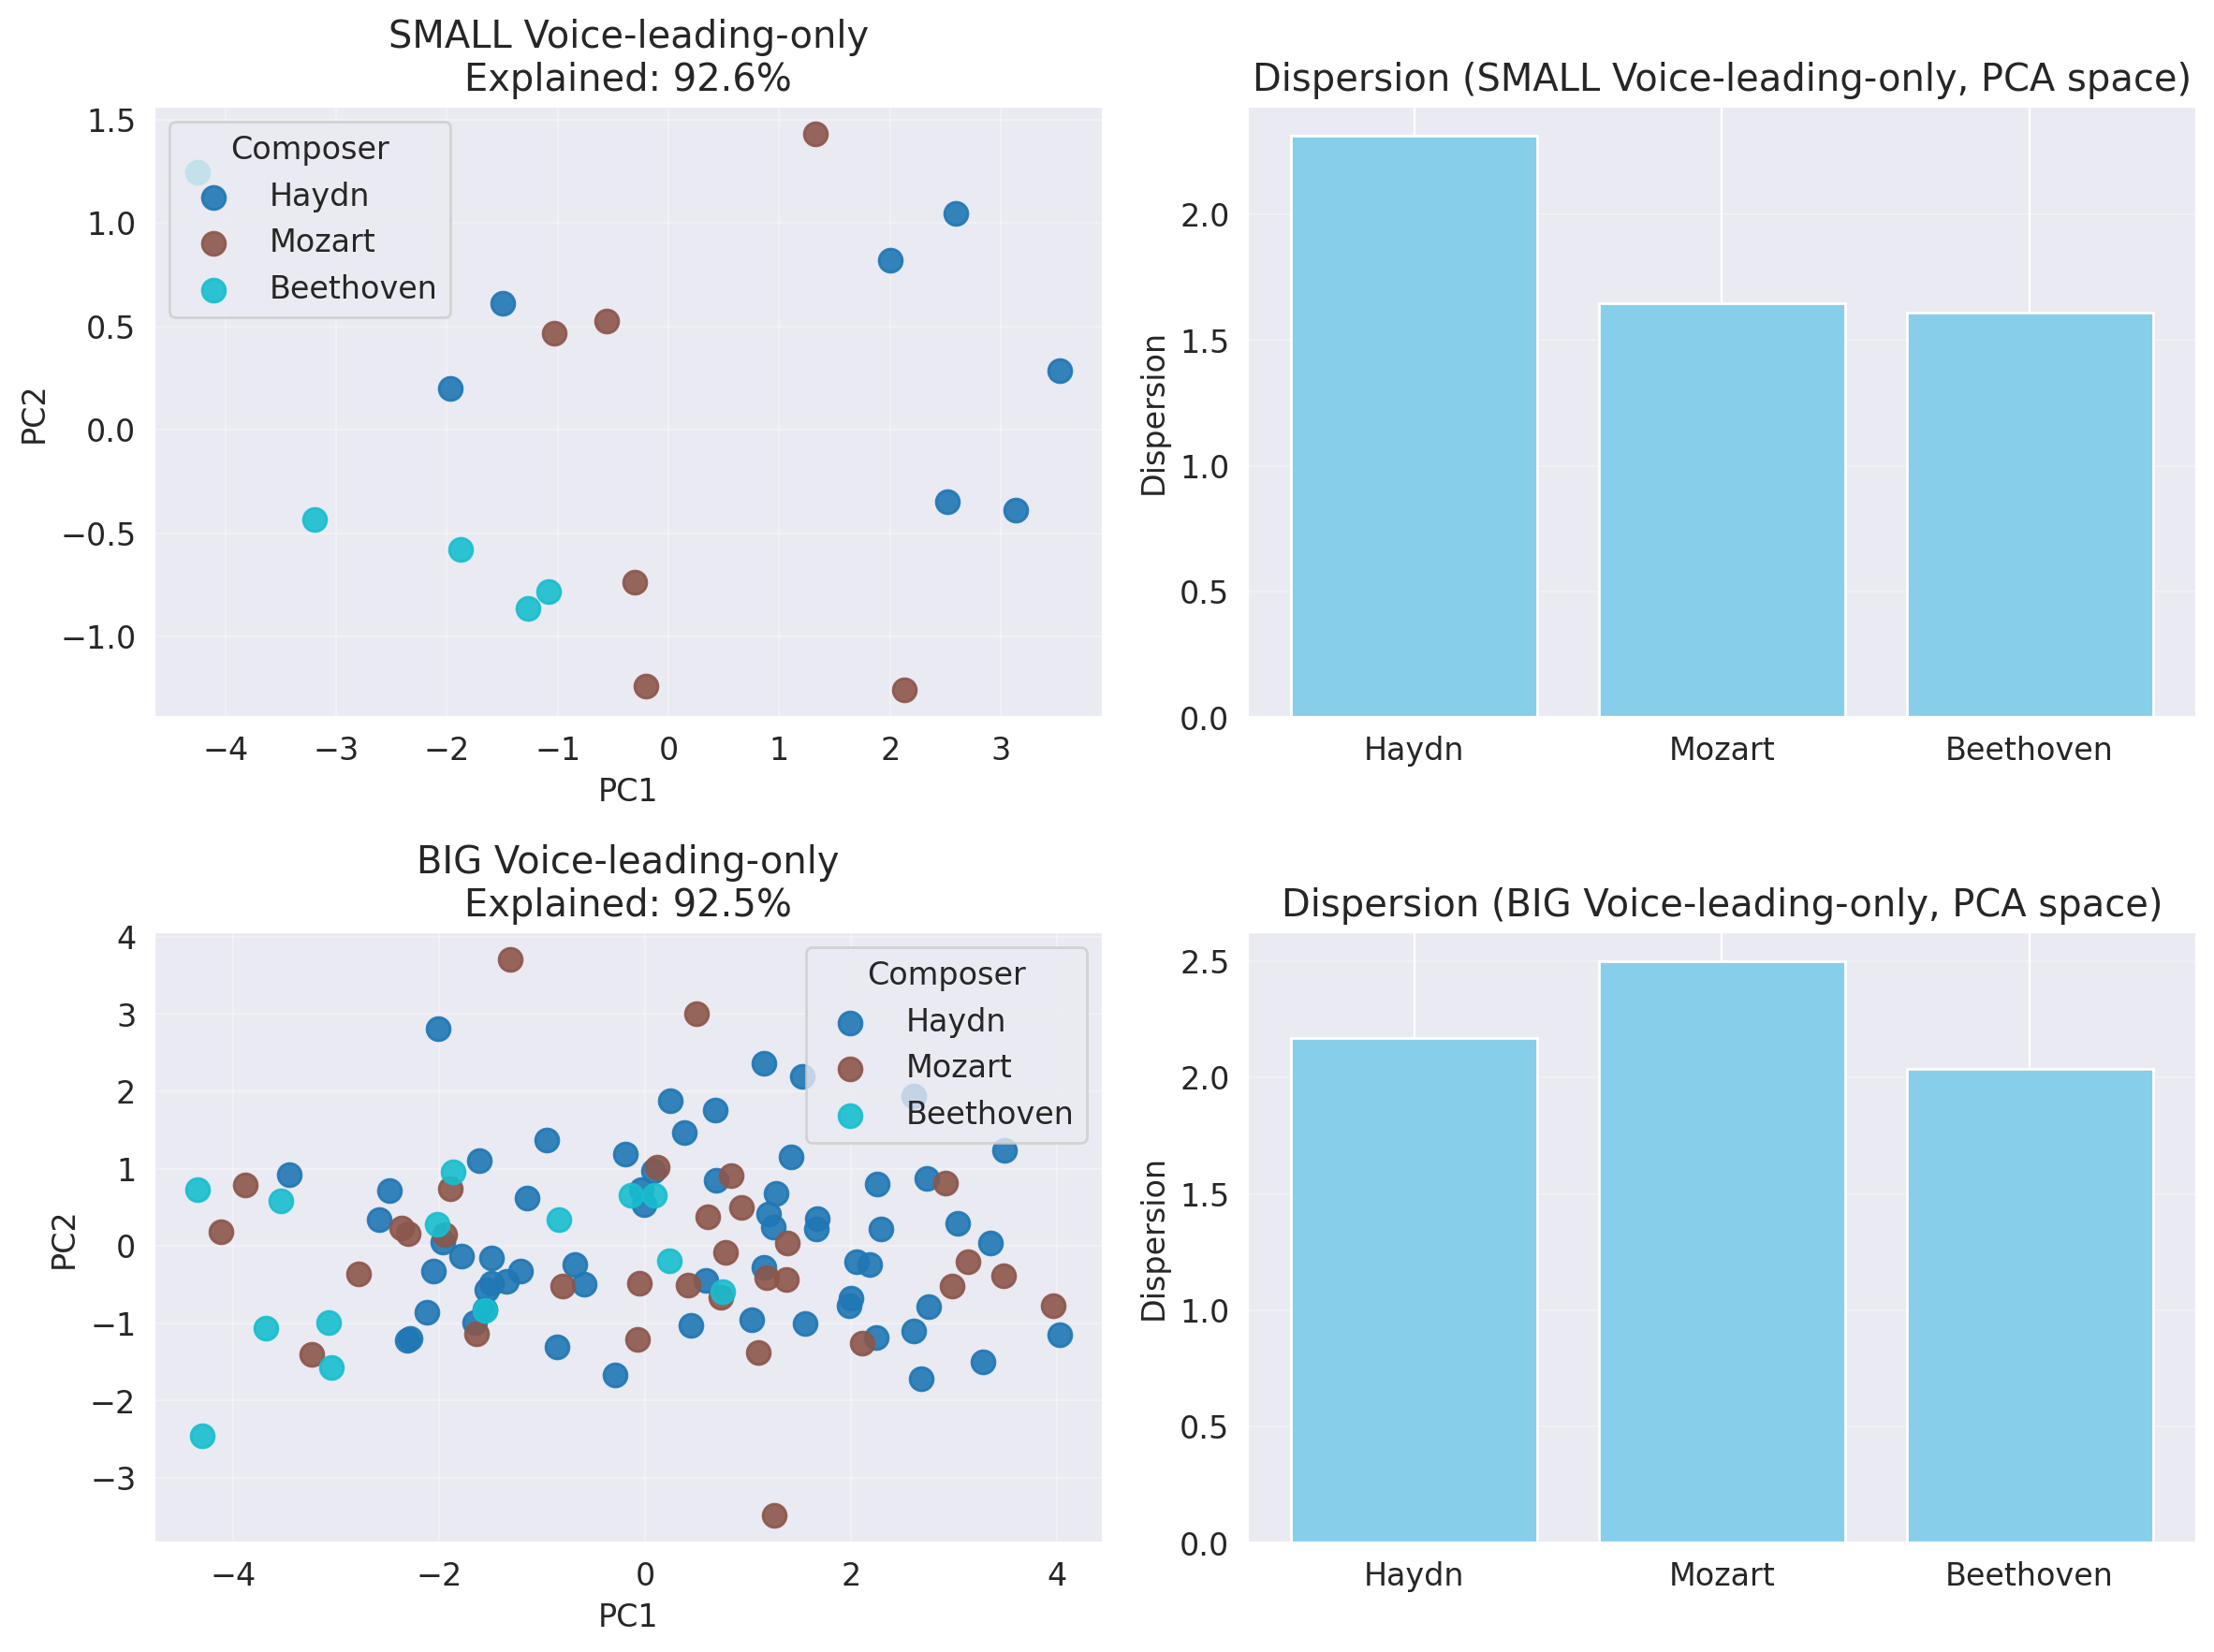

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

plot_pca_and_dispersion(X_small_voice, "SMALL Voice-leading-only", axes[0, 0], axes[0, 1], y_small_voice, scale=False)
plot_pca_and_dispersion(X_big_voice, "BIG Voice-leading-only", axes[1, 0], axes[1, 1], y_big_voice, scale=False)

plt.tight_layout()
plt.show()

,composer,filename
0,Beethoven,quartet01-3.mid
1,Haydn,op17n2-02.mid
2,Mozart,k158-03.mid


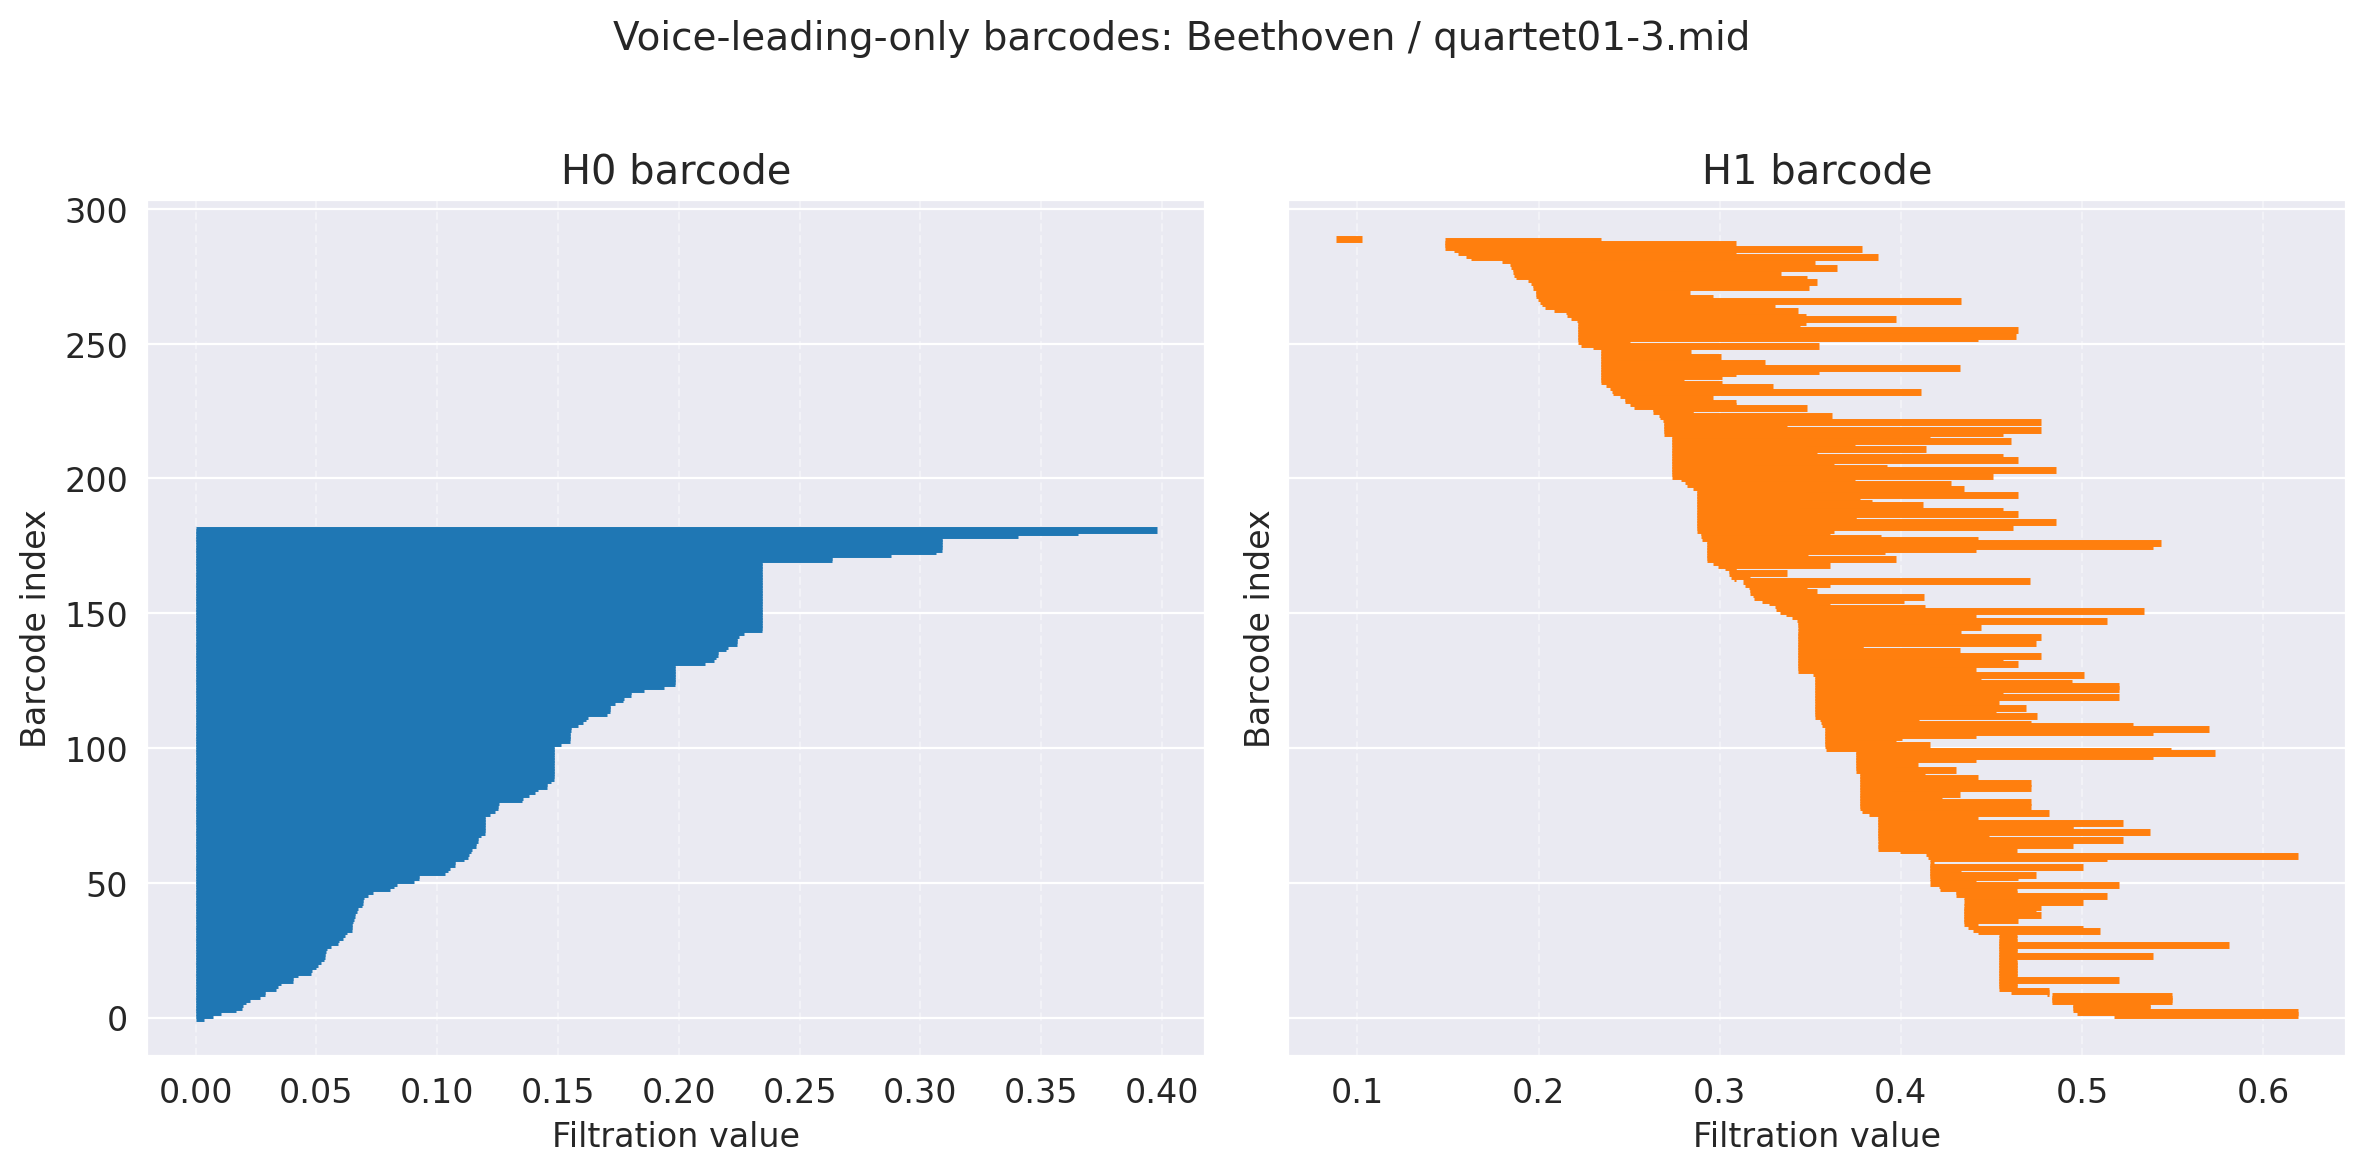

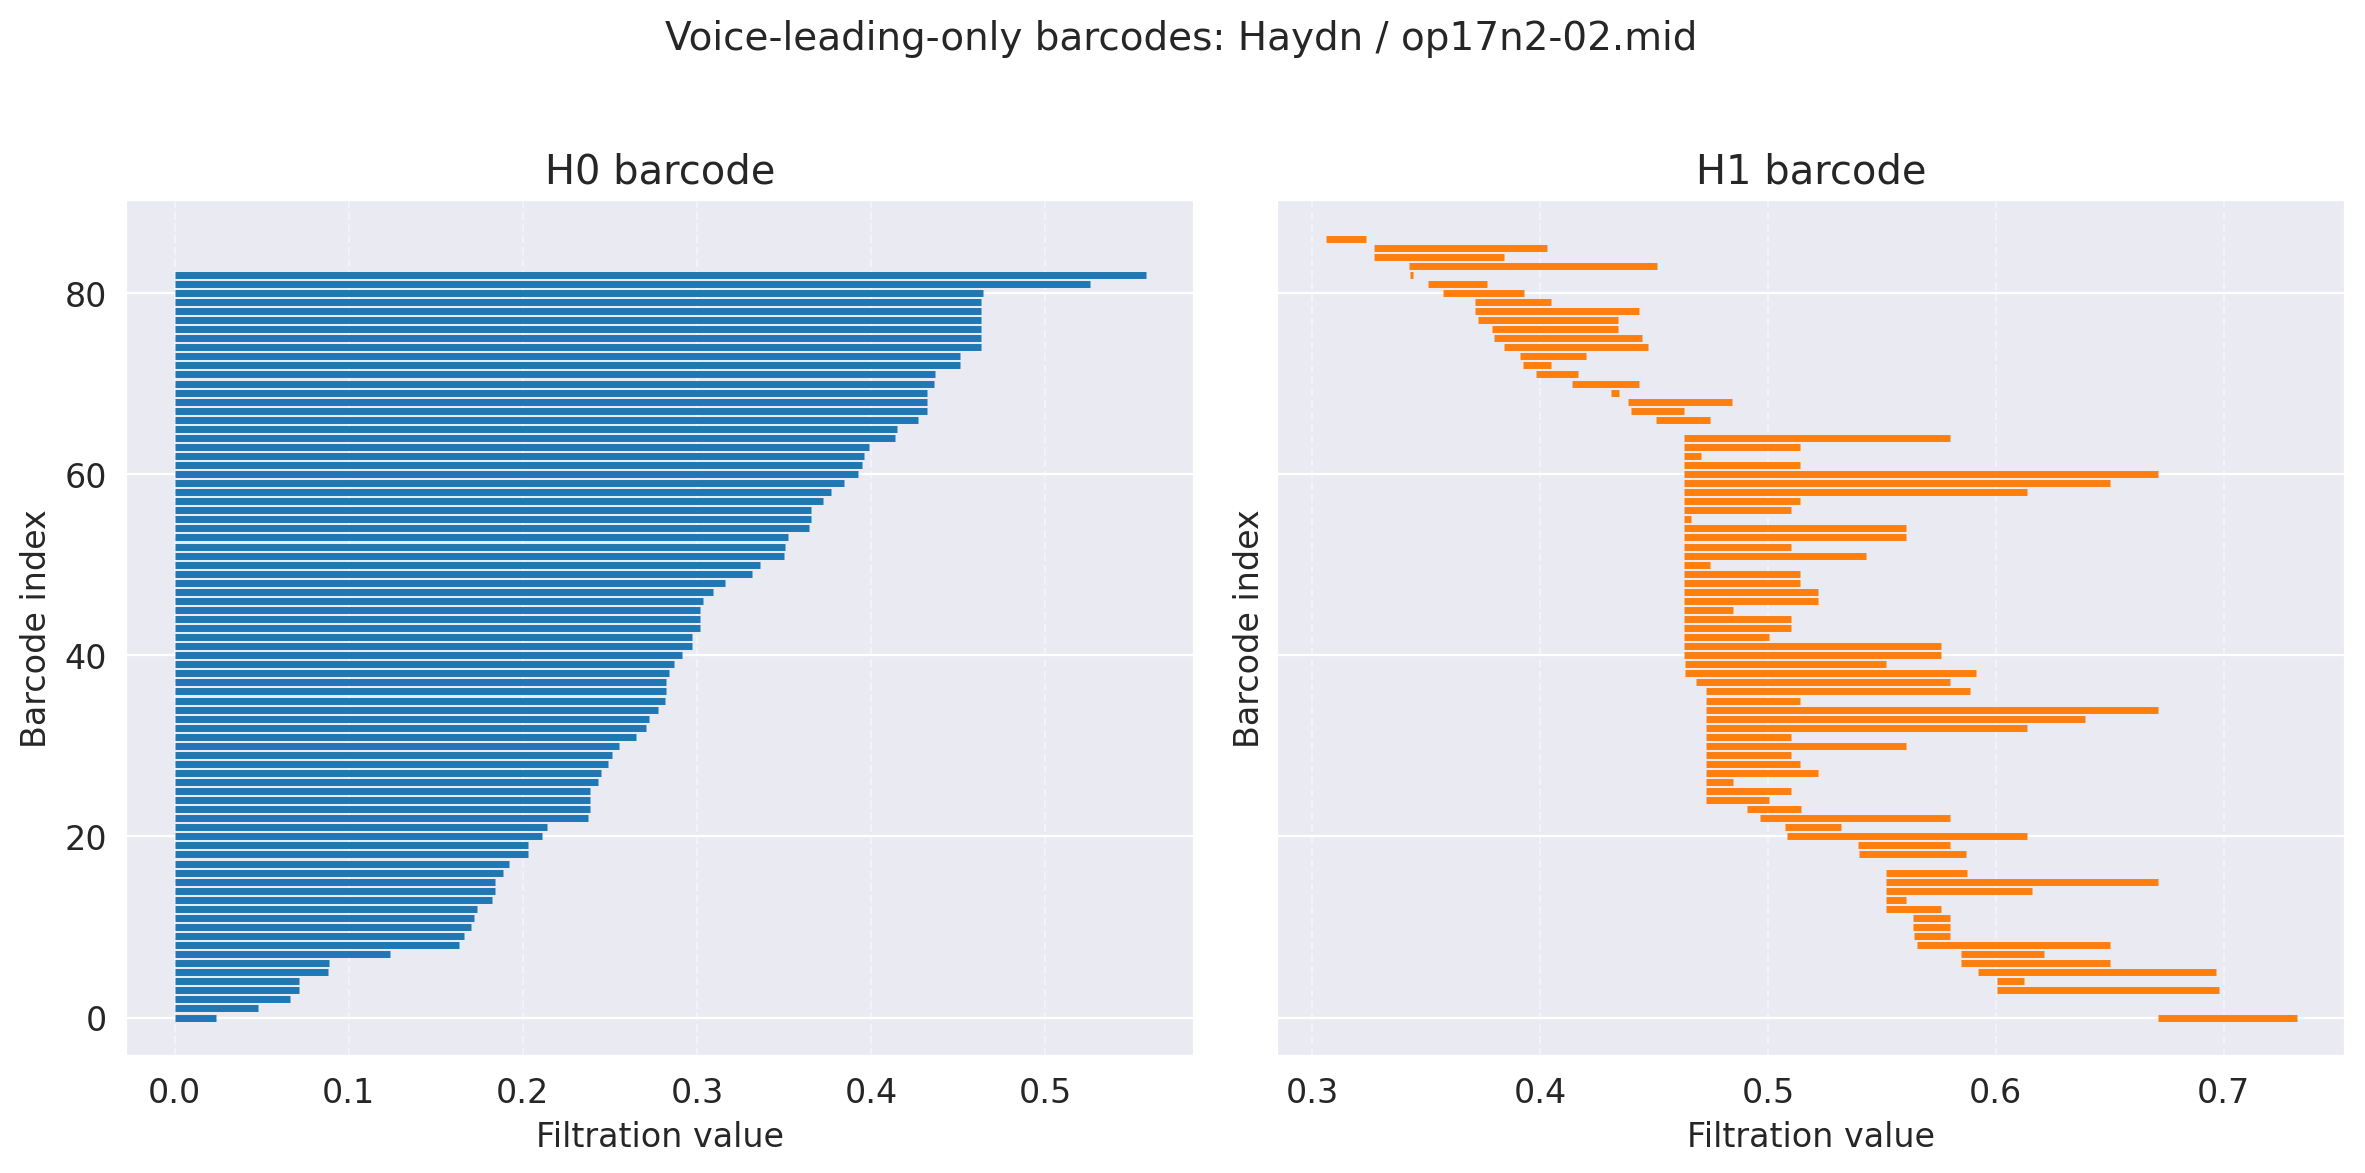

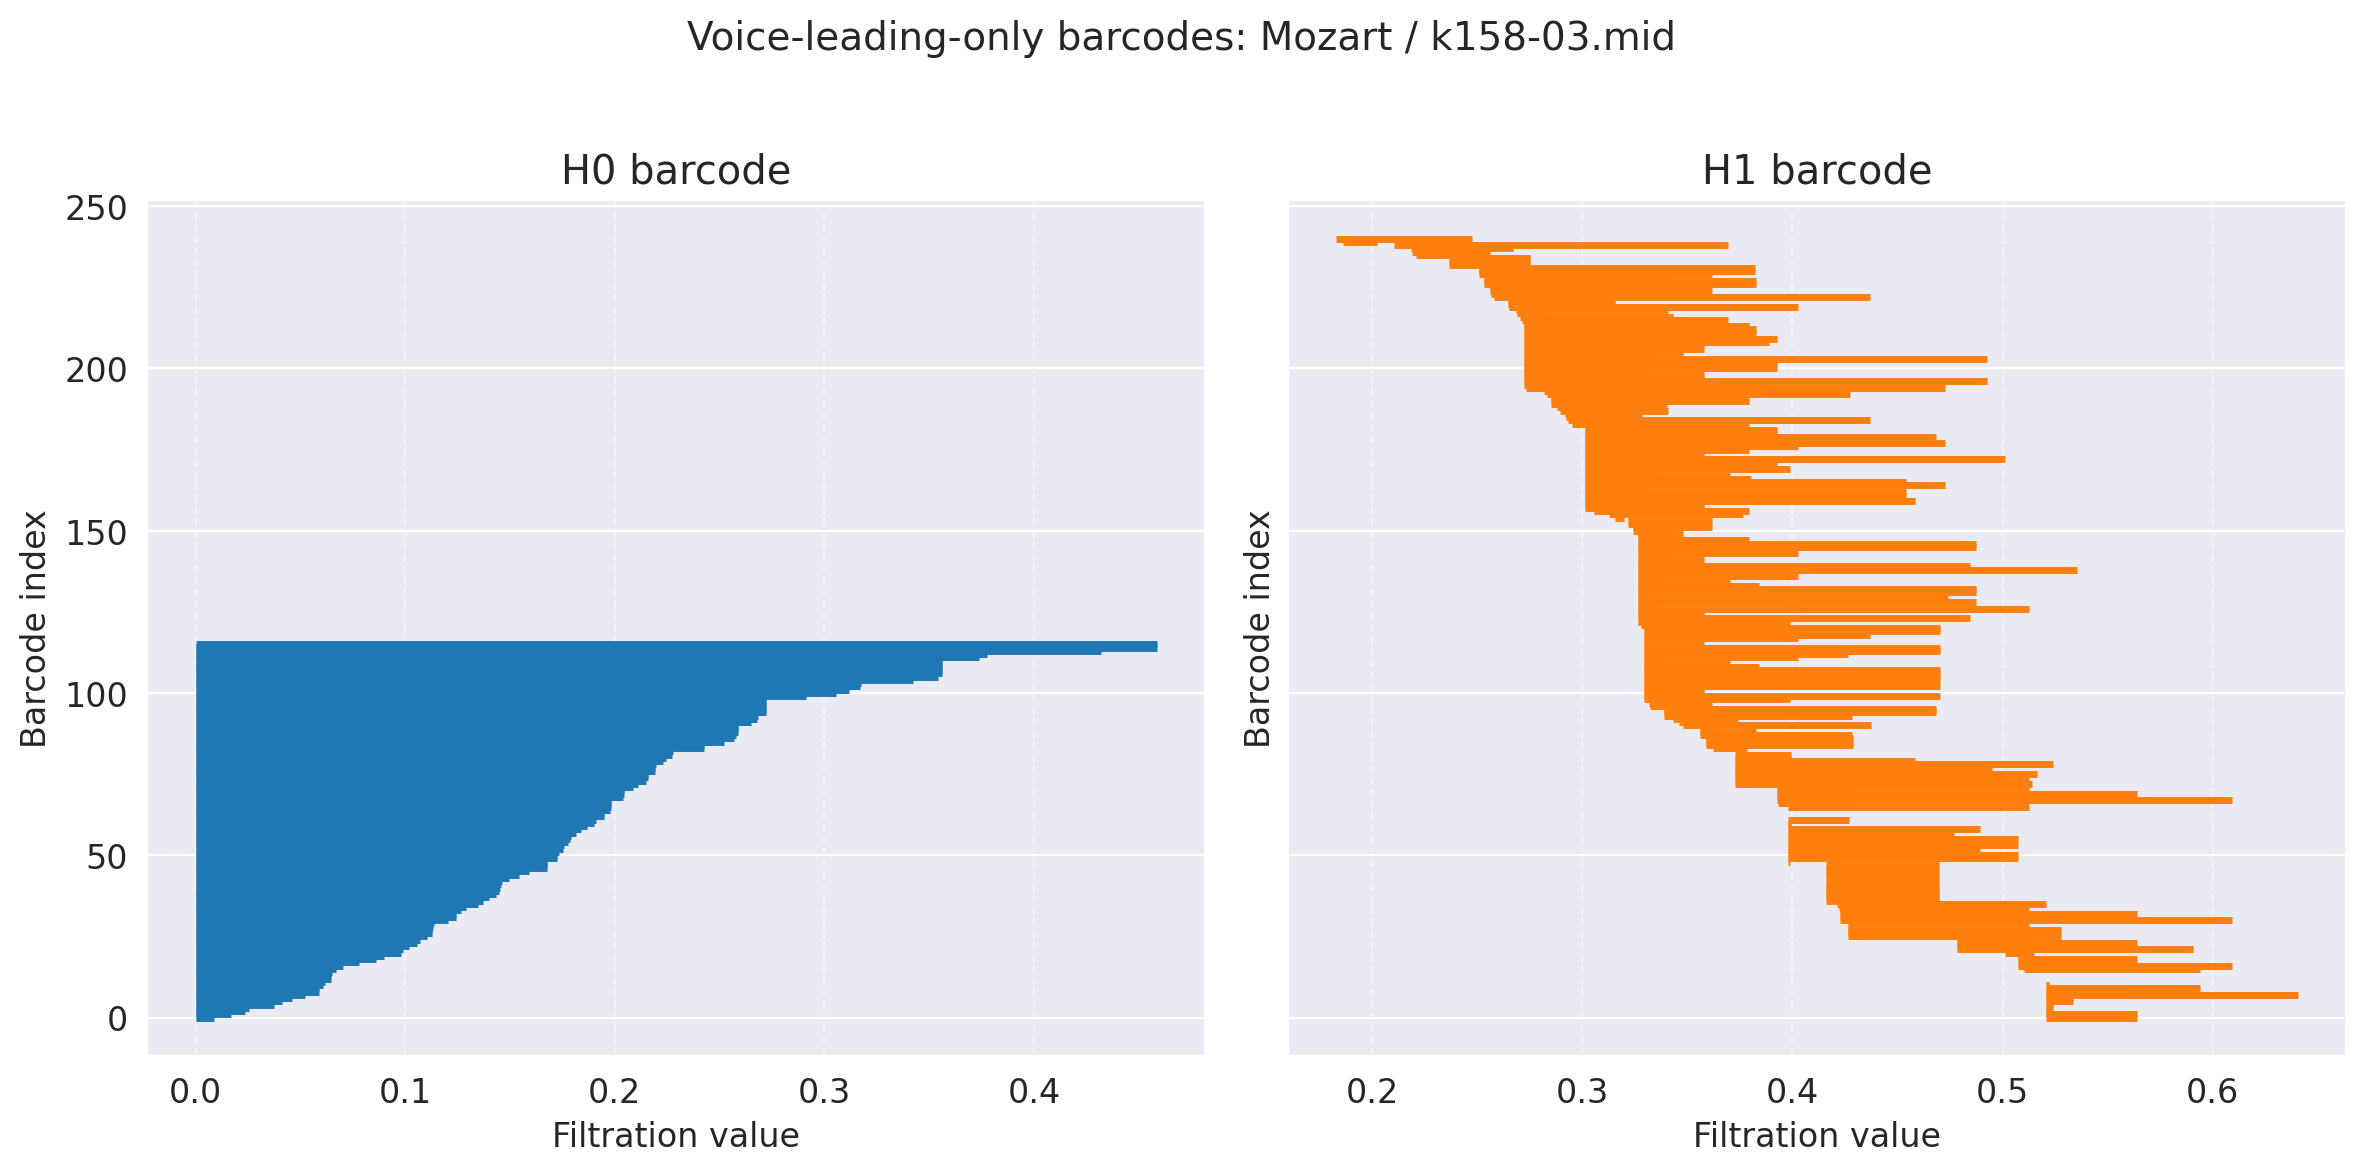

In [44]:
small_voice_examples = (df_small_voice.groupby("composer", as_index=False).first()[["composer", "filename"]])
display(small_voice_examples)

for _, row in small_voice_examples.iterrows():
    plot_voice_barcodes_for_piece(
        row["filename"],
        event_cache_small,
        VOICE_INTERVAL_MODULUS,
        title=f"Voice-leading-only barcodes: {row['composer']} / {row['filename']}",
        rest_cost=VOICE_REST_COST,
        unique_only=True,
        round_decimals=6,
        maxdim=1
    )

In [46]:
df_small_voice.to_csv("./tables/df_small_voice_features_ch2.csv", index=False)
df_big_voice.to_csv("./tables/df_big_voice_features_ch2.csv", index=False)
df_voice_eval_summary.to_csv("./tables/voice_eval_summary.csv", index=False)
df_small_voice_dispersion.to_csv("./tables/voice_small_dispersion.csv", index=False)
df_big_voice_dispersion.to_csv("./tables/voice_big_dispersion.csv", index=False)
df_small_voice_centroids.to_csv("./tables/voice_small_centroid_distances.csv")
df_big_voice_centroids.to_csv("./tables/voice_big_centroid_distances.csv")
df_small_voice_pca_disp.to_csv("./tables/voice_small_pca_dispersion.csv", index=False)
df_big_voice_pca_disp.to_csv("./tables/voice_big_pca_dispersion.csv", index=False)

print("Saved:")
print("./tables/df_small_voice_features_ch2.csv")
print("./tables/df_big_voice_features_ch2.csv")
print("./tables/voice_eval_summary.csv")
print("./tables/voice_small_dispersion.csv")
print("./tables/voice_big_dispersion.csv")
print("./tables/voice_small_centroid_distances.csv")
print("./tables/voice_big_centroid_distances.csv")
print("./tables/voice_small_pca_dispersion.csv")
print("./tables/voice_big_pca_dispersion.csv")

Saved:
./tables/df_small_voice_features_ch2.csv
./tables/df_big_voice_features_ch2.csv
./tables/voice_eval_summary.csv
./tables/voice_small_dispersion.csv
./tables/voice_big_dispersion.csv
./tables/voice_small_centroid_distances.csv
./tables/voice_big_centroid_distances.csv
./tables/voice_small_pca_dispersion.csv
./tables/voice_big_pca_dispersion.csv


The voice-leading branch provides a stronger stylistic signal on the focused small dataset than the harmonic-only branch. The model uses directed interval classes modulo \(24\), together with two rest-related states, so each transition object is represented in a \(26\)-state space. On the small dataset, the first two principal components explain \(0.9262\) of the variance, which is higher than in the harmonic-only model. More importantly, both silhouette scores become positive: \(0.0632\) in the full standardized feature space and \(0.0892\) in the PCA plane. The Davies-Bouldin index also decreases to \(2.1597\), and the leave-one-out 1-NN accuracy increases to \(0.7222\). Thus, on the focused corpus, voice-leading information gives a clearer composer-related organization than harmonic content alone.

The class geometry supports the same interpretation. In the small dataset, Beethoven is well separated from the other two composers: the Beethoven-Haydn centroid distance is \(3.8773\), and the Beethoven-Mozart distance is \(2.5790\), while the Haydn-Mozart distance is only \(1.3665\). The dispersion values also show that Haydn is the most diffuse class, whereas Mozart and Beethoven are more compact. This suggests that the motion-based representation captures stylistic differences that are not visible from vertical harmonic content alone.

On the large dataset, however, the effect is weaker. The first two principal components still explain a very large proportion of the variance, \(0.9250\), but the class-separation metrics do not improve relative to the harmonic-only branch. The silhouette scores remain negative, \(-0.0541\) in the full feature space and \(-0.0615\) in the PCA plane, and the Davies-Bouldin index is \(7.8896\). The leave-one-out 1-NN accuracy is \(0.4815\), which is lower than for the harmonic-only model on the same dataset. Nevertheless, the centroid distances again show the same broad pattern: Haydn and Mozart remain close to each other, with distance \(0.4065\), while Beethoven lies farther away from both Haydn and Mozart.

Overall, the voice-leading model is especially effective in the focused corpus, where it gives the best separation among the single-branch models. On the larger and more heterogeneous corpus, its advantage becomes less stable: it preserves a clear low-dimensional structure, but composer classes still overlap substantially. This suggests that voice-leading information captures an important aspect of stylistic motion, but by itself it is not sufficient for robust three-way composer separation across a broader mixed-genre dataset. This motivates the late-fusion experiment, where harmonic and voice-leading descriptors are combined in a single feature representation.

## **Late-fusion model**

### Late-fusion feature tables

In [48]:
df_small_fusion = build_fusion_feature_table(df_small_harm, df_small_voice)
df_big_fusion = build_fusion_feature_table(df_big_harm, df_big_voice)

print("SMALL late-fusion table shape:", df_small_fusion.shape)
print("BIG late-fusion table shape:", df_big_fusion.shape)

SMALL late-fusion table shape: (18, 40)
BIG late-fusion table shape: (108, 40)


In [49]:
FUSION_CORE_COLS = HARM_CORE_COLS + VOICE_CORE_COLS
FUSION_AUX_COLS = HARM_AUX_COLS + VOICE_AUX_COLS

fusion_cols = FUSION_CORE_COLS

print("Number of late-fusion core features:", len(FUSION_CORE_COLS))
print("Number of late-fusion auxiliary features:", len(FUSION_AUX_COLS))

Number of late-fusion core features: 12
Number of late-fusion auxiliary features: 4


### Late-fusion evaluation

In [50]:
df_small_fusion_summary, df_small_fusion_dispersion, df_small_fusion_centroids, df_small_fusion_pca_disp, X_small_fusion, Z_small_fusion, y_small_fusion, pca_small_fusion = evaluate_branch(
    df_small_fusion,
    fusion_cols,
    label_col="composer",
    dataset_name="SMALL",
    model_name="Late-fusion"
)

df_big_fusion_summary, df_big_fusion_dispersion, df_big_fusion_centroids, df_big_fusion_pca_disp, X_big_fusion, Z_big_fusion, y_big_fusion, pca_big_fusion = evaluate_branch(
    df_big_fusion,
    fusion_cols,
    label_col="composer",
    dataset_name="BIG",
    model_name="Late-fusion"
)

df_fusion_eval_summary = pd.concat(
    [df_small_fusion_summary, df_big_fusion_summary],
    ignore_index=True
)

display(df_fusion_eval_summary)

,dataset,model,label_col,n_samples,n_features,pc1_variance,pc2_variance,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,max_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,SMALL,Late-fusion,composer,18,12,0.570187,0.189145,0.759332,0.056674,0.067908,2.593086,3.128913,3.589756,1.860878,3.149680,4.176119,0.555556,0.611111
1,BIG,Late-fusion,composer,108,12,0.548176,0.152678,0.700854,-0.047465,-0.069963,7.945783,3.281295,3.703700,0.609170,2.031501,2.884018,0.546296,0.462963


In [51]:
print("SMALL within-class dispersion")
display(df_small_fusion_dispersion)

print("SMALL centroid distances")
display(df_small_fusion_centroids)

print("SMALL PCA-space dispersion")
display(df_small_fusion_pca_disp)

print("BIG within-class dispersion")
display(df_big_fusion_dispersion)

print("BIG centroid distances")
display(df_big_fusion_centroids)

print("BIG PCA-space dispersion")
display(df_big_fusion_pca_disp)

SMALL within-class dispersion


,label,n_samples,mean_distance,median_distance,max_distance,rms_distance
0,Haydn,7,3.148587,3.244166,4.599507,3.589756
1,Mozart,6,2.737429,2.583519,4.165451,3.114918
2,Beethoven,5,2.220932,1.811296,3.760389,2.682065


SMALL centroid distances


,Haydn,Mozart,Beethoven
Haydn,0.000000,1.860878,4.176119
Mozart,1.860878,0.000000,3.412041
Beethoven,4.176119,3.412041,0.000000


SMALL PCA-space dispersion


...

,label,n_samples,mean_distance,median_distance,max_distance,rms_distance
0,Haydn,62,3.132011,2.937606,5.771435,3.299601
1,Mozart,32,3.424140,3.400006,5.729795,3.703700
2,Beethoven,14,2.591358,2.608734,4.459940,2.840583


BIG centroid distances


,Haydn,Mozart,Beethoven
Haydn,0.000000,0.609170,2.884018
Mozart,0.609170,0.000000,2.601315
Beethoven,2.884018,2.601315,0.000000


BIG PCA-space dispersion


,label,n_samples,pca_dispersion
0,Haydn,62,2.709101
1,Mozart,32,3.111306
2,Beethoven,14,2.314492


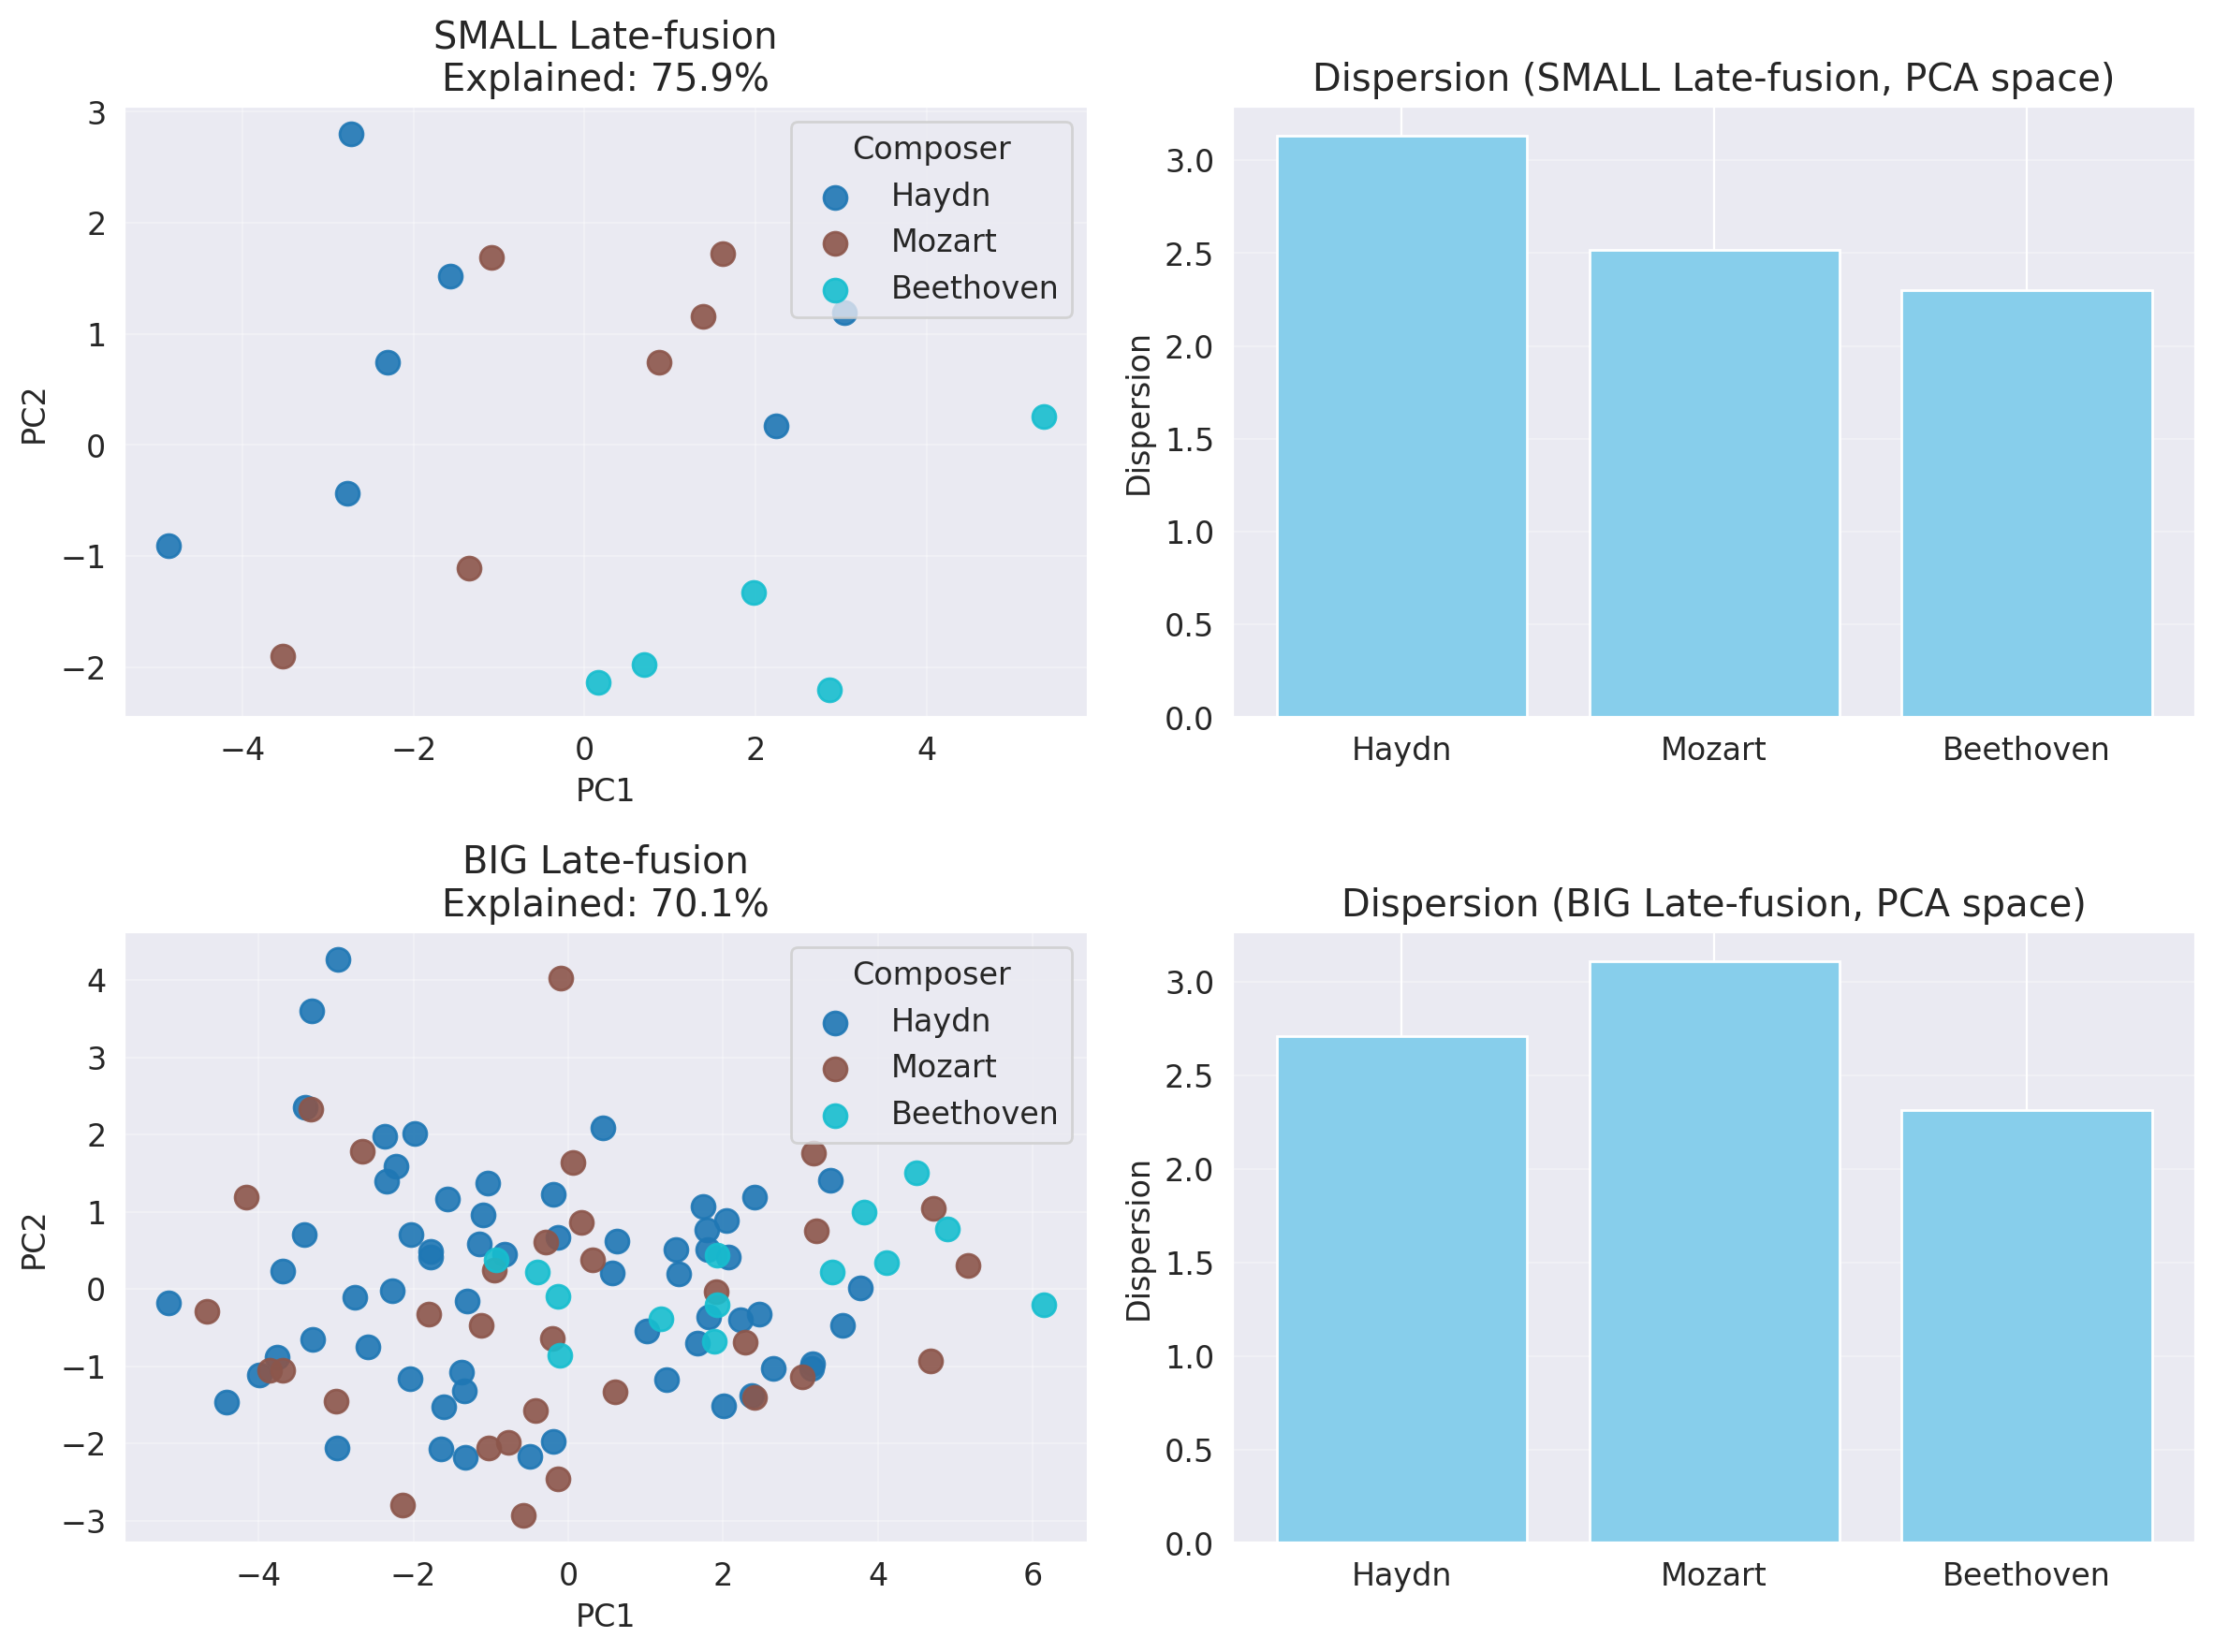

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

plot_pca_and_dispersion(X_small_fusion, "SMALL Late-fusion", axes[0, 0], axes[0, 1], y_small_fusion, scale=False,)
plot_pca_and_dispersion(X_big_fusion, "BIG Late-fusion", axes[1, 0], axes[1, 1], y_big_fusion, scale=False,)

plt.tight_layout()
plt.show()

The late-fusion model combines the harmonic and voice-leading barcode statistics in a single feature vector. In the present experiment, no auxiliary size descriptors are added, so the fusion vector consists of \(12\) features: six harmonic topological summaries and six voice-leading topological summaries.

On the small dataset, late fusion preserves a meaningful composer-related structure, but it does not outperform the voice-leading branch alone. The first two principal components explain \(0.7593\) of the variance. The full-space silhouette is positive, \(0.0567\), and the PCA-plane silhouette is also positive, \(0.0679\), but both values are slightly lower than for the voice-leading-only model. The Davies-Bouldin index equals \(2.5931\), which improves over the harmonic-only model but remains worse than the voice-leading-only value. The leave-one-out 1-NN accuracy is \(0.5556\), again between the harmonic-only and voice-leading-only results.

The centroid geometry nevertheless shows that the fused representation increases global separation between composer centers. On the small dataset, the mean centroid distance is \(3.1497\), which is larger than for both single-branch models. The Beethoven centroid is especially separated from the Haydn and Mozart centroids, with distances \(4.1761\) and \(3.4120\), respectively. At the same time, the within-class dispersions also increase, so the larger centroid separation does not translate into uniformly better clustering scores.

On the large dataset, late fusion gives a mixed result. The first two principal components explain \(0.7009\) of the variance, which is lower than in both single-branch models. The silhouette scores remain negative, but the full-space silhouette \(-0.0475\) is slightly better than for the harmonic-only and voice-leading-only branches. The nearest-centroid accuracy also improves to \(0.4630\), while the 1-NN accuracy remains equal to the harmonic-only value, \(0.5463\). However, the Davies-Bouldin index increases to \(7.9458\), indicating that the fused space also introduces additional within-class spread.

Thus, late fusion should not be interpreted as a uniformly superior model. Its main effect is to combine complementary harmonic and motion-based information, which increases centroid separation and slightly improves some large-dataset criteria. However, on the focused corpus the voice-leading-only model remains the strongest branch according to the main clustering and classification metrics. This suggests that simple feature concatenation is useful as a diagnostic fusion strategy, but it does not automatically produce the best stylistic geometry.

## Model comparison

In [53]:
df_small_model_comparison = pd.concat(
    [df_small_harm_summary, df_small_voice_summary, df_small_fusion_summary],
    ignore_index=True
)

df_big_model_comparison = pd.concat(
    [df_big_harm_summary, df_big_voice_summary, df_big_fusion_summary],
    ignore_index=True
)

display(df_small_model_comparison)
display(df_big_model_comparison)

,dataset,model,label_col,n_samples,n_features,pc1_variance,pc2_variance,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,max_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,SMALL,Harmonic-only,composer,18,6,0.556041,0.263838,0.819879,-0.016314,-0.067480,3.180944,2.416113,2.629445,1.263105,1.682795,2.234020,0.444444,0.555556
1,SMALL,Voice-leading-only,composer,18,6,0.813627,0.112615,0.926242,0.063247,0.089220,2.159743,1.978416,2.443842,1.366541,2.607614,3.877314,0.722222,0.666667
2,SMALL,Late-fusion,composer,18,12,0.570187,0.189145,0.759332,0.056674,0.067908,2.593086,3.128913,3.589756,1.860878,3.149680,4.176119,0.555556,0.611111


,dataset,model,label_col,n_samples,n_features,pc1_variance,pc2_variance,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,max_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,BIG,Harmonic-only,composer,108,6,0.500170,0.286712,0.786882,-0.053321,-0.077835,7.646570,2.307071,2.633998,0.453710,1.218713,1.638626,0.546296,0.425926
1,BIG,Voice-leading-only,composer,108,6,0.716701,0.208346,0.925047,-0.054143,-0.061520,7.889614,2.330442,2.603737,0.406491,1.619521,2.373282,0.481481,0.425926
2,BIG,Late-fusion,composer,108,12,0.548176,0.152678,0.700854,-0.047465,-0.069963,7.945783,3.281295,3.703700,0.609170,2.031501,2.884018,0.546296,0.462963


In [54]:
COMPARISON_COLS = ["dataset", "model", "n_samples", "n_features", "pc12_variance",
    "silhouette_full", "silhouette_pca2", "davies_bouldin", "mean_within_class_rms",
    "min_centroid_distance", "mean_centroid_distance","max_centroid_distance",
    "loo_1nn_accuracy", "loo_nearest_centroid_accuracy",
]

print("SMALL model comparison")
display(df_small_model_comparison[COMPARISON_COLS])

print("BIG model comparison")
display(df_big_model_comparison[COMPARISON_COLS])

SMALL model comparison


,dataset,model,n_samples,n_features,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,SMALL,Harmonic-only,18,6,0.819879,-0.016314,-0.067480,3.180944,2.416113,1.263105,1.682795,2.234020,0.444444,0.555556
1,SMALL,Voice-leading-only,18,6,0.926242,0.063247,0.089220,2.159743,1.978416,1.366541,2.607614,3.877314,0.722222,0.666667
2,SMALL,Late-fusion,18,12,0.759332,0.056674,0.067908,2.593086,3.128913,1.860878,3.149680,4.176119,0.555556,0.611111


BIG model comparison


,dataset,model,n_samples,n_features,pc12_variance,silhouette_full,silhouette_pca2,davies_bouldin,mean_within_class_rms,min_centroid_distance,mean_centroid_distance,max_centroid_distance,loo_1nn_accuracy,loo_nearest_centroid_accuracy
0,BIG,Harmonic-only,108,6,0.786882,-0.053321,-0.077835,7.646570,2.307071,0.453710,1.218713,1.638626,0.546296,0.425926
1,BIG,Voice-leading-only,108,6,0.925047,-0.054143,-0.061520,7.889614,2.330442,0.406491,1.619521,2.373282,0.481481,0.425926
2,BIG,Late-fusion,108,12,0.700854,-0.047465,-0.069963,7.945783,3.281295,0.609170,2.031501,2.884018,0.546296,0.462963


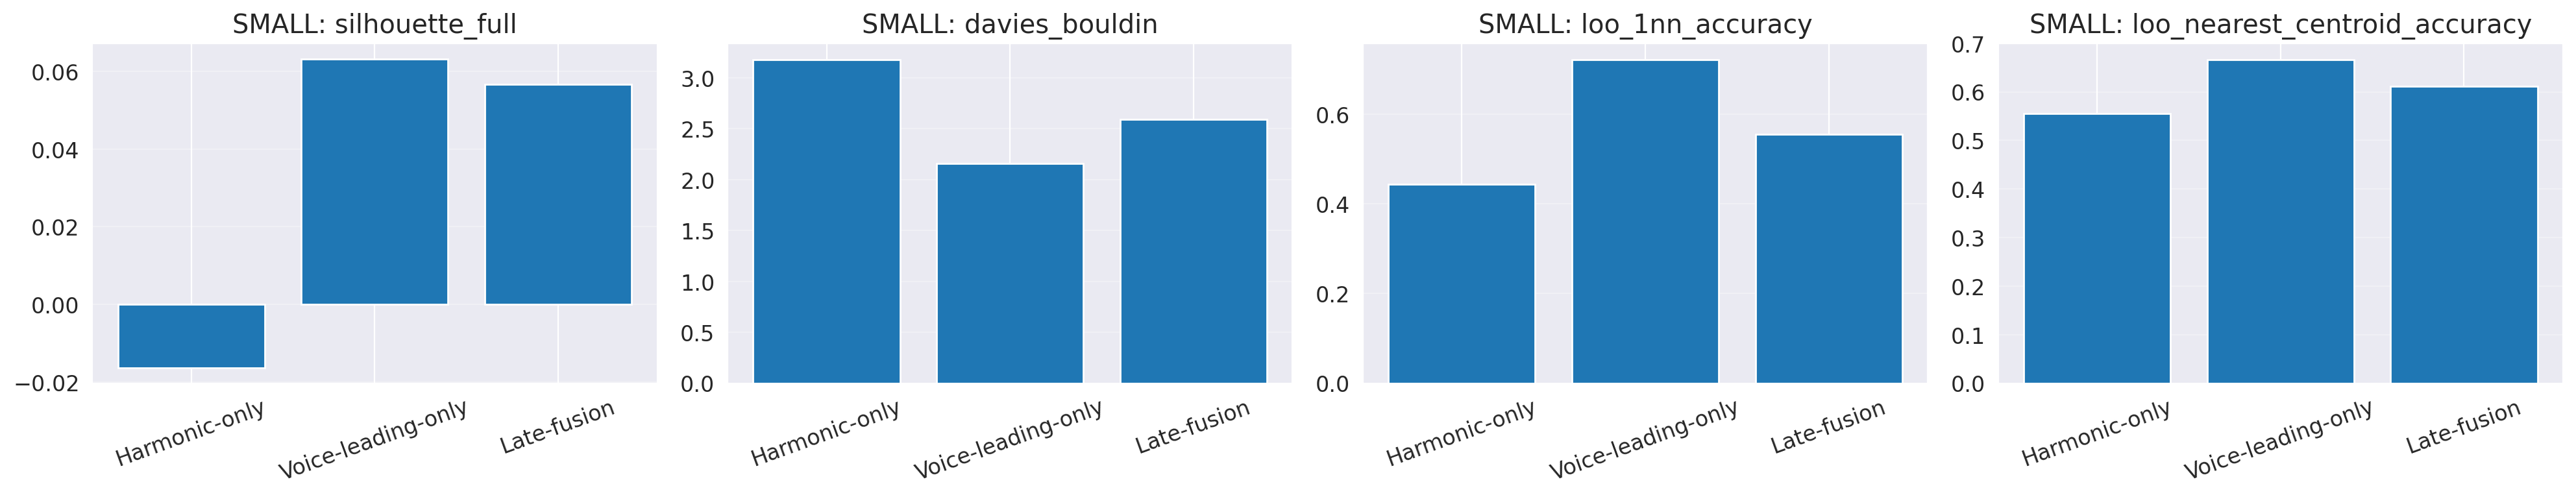

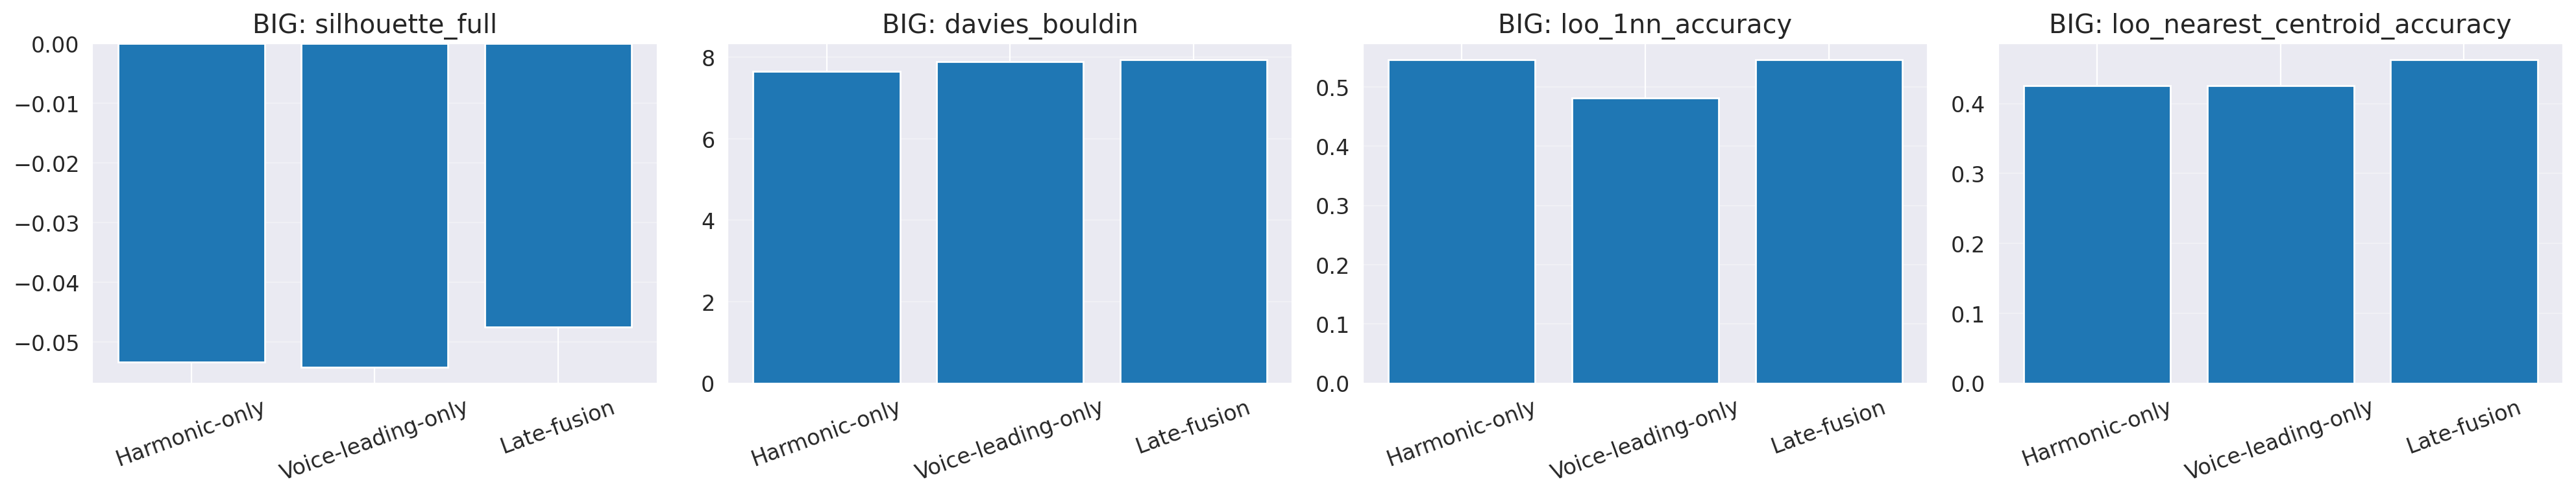

In [55]:
plot_model_metric_comparison(df_small_model_comparison,
    "SMALL",
    ["silhouette_full", "davies_bouldin", "loo_1nn_accuracy", "loo_nearest_centroid_accuracy"]
)

plot_model_metric_comparison(
    df_big_model_comparison,
    "BIG",
    ["silhouette_full", "davies_bouldin", "loo_1nn_accuracy", "loo_nearest_centroid_accuracy"]
)

,composer,filename,filepath
0,Beethoven,quartet01-3.mid,/content/ITG-JS-persistent-homology/data/raw/c...
1,Haydn,op17n2-02.mid,/content/ITG-JS-persistent-homology/data/raw/c...
2,Mozart,k158-03.mid,/content/ITG-JS-persistent-homology/data/raw/c...


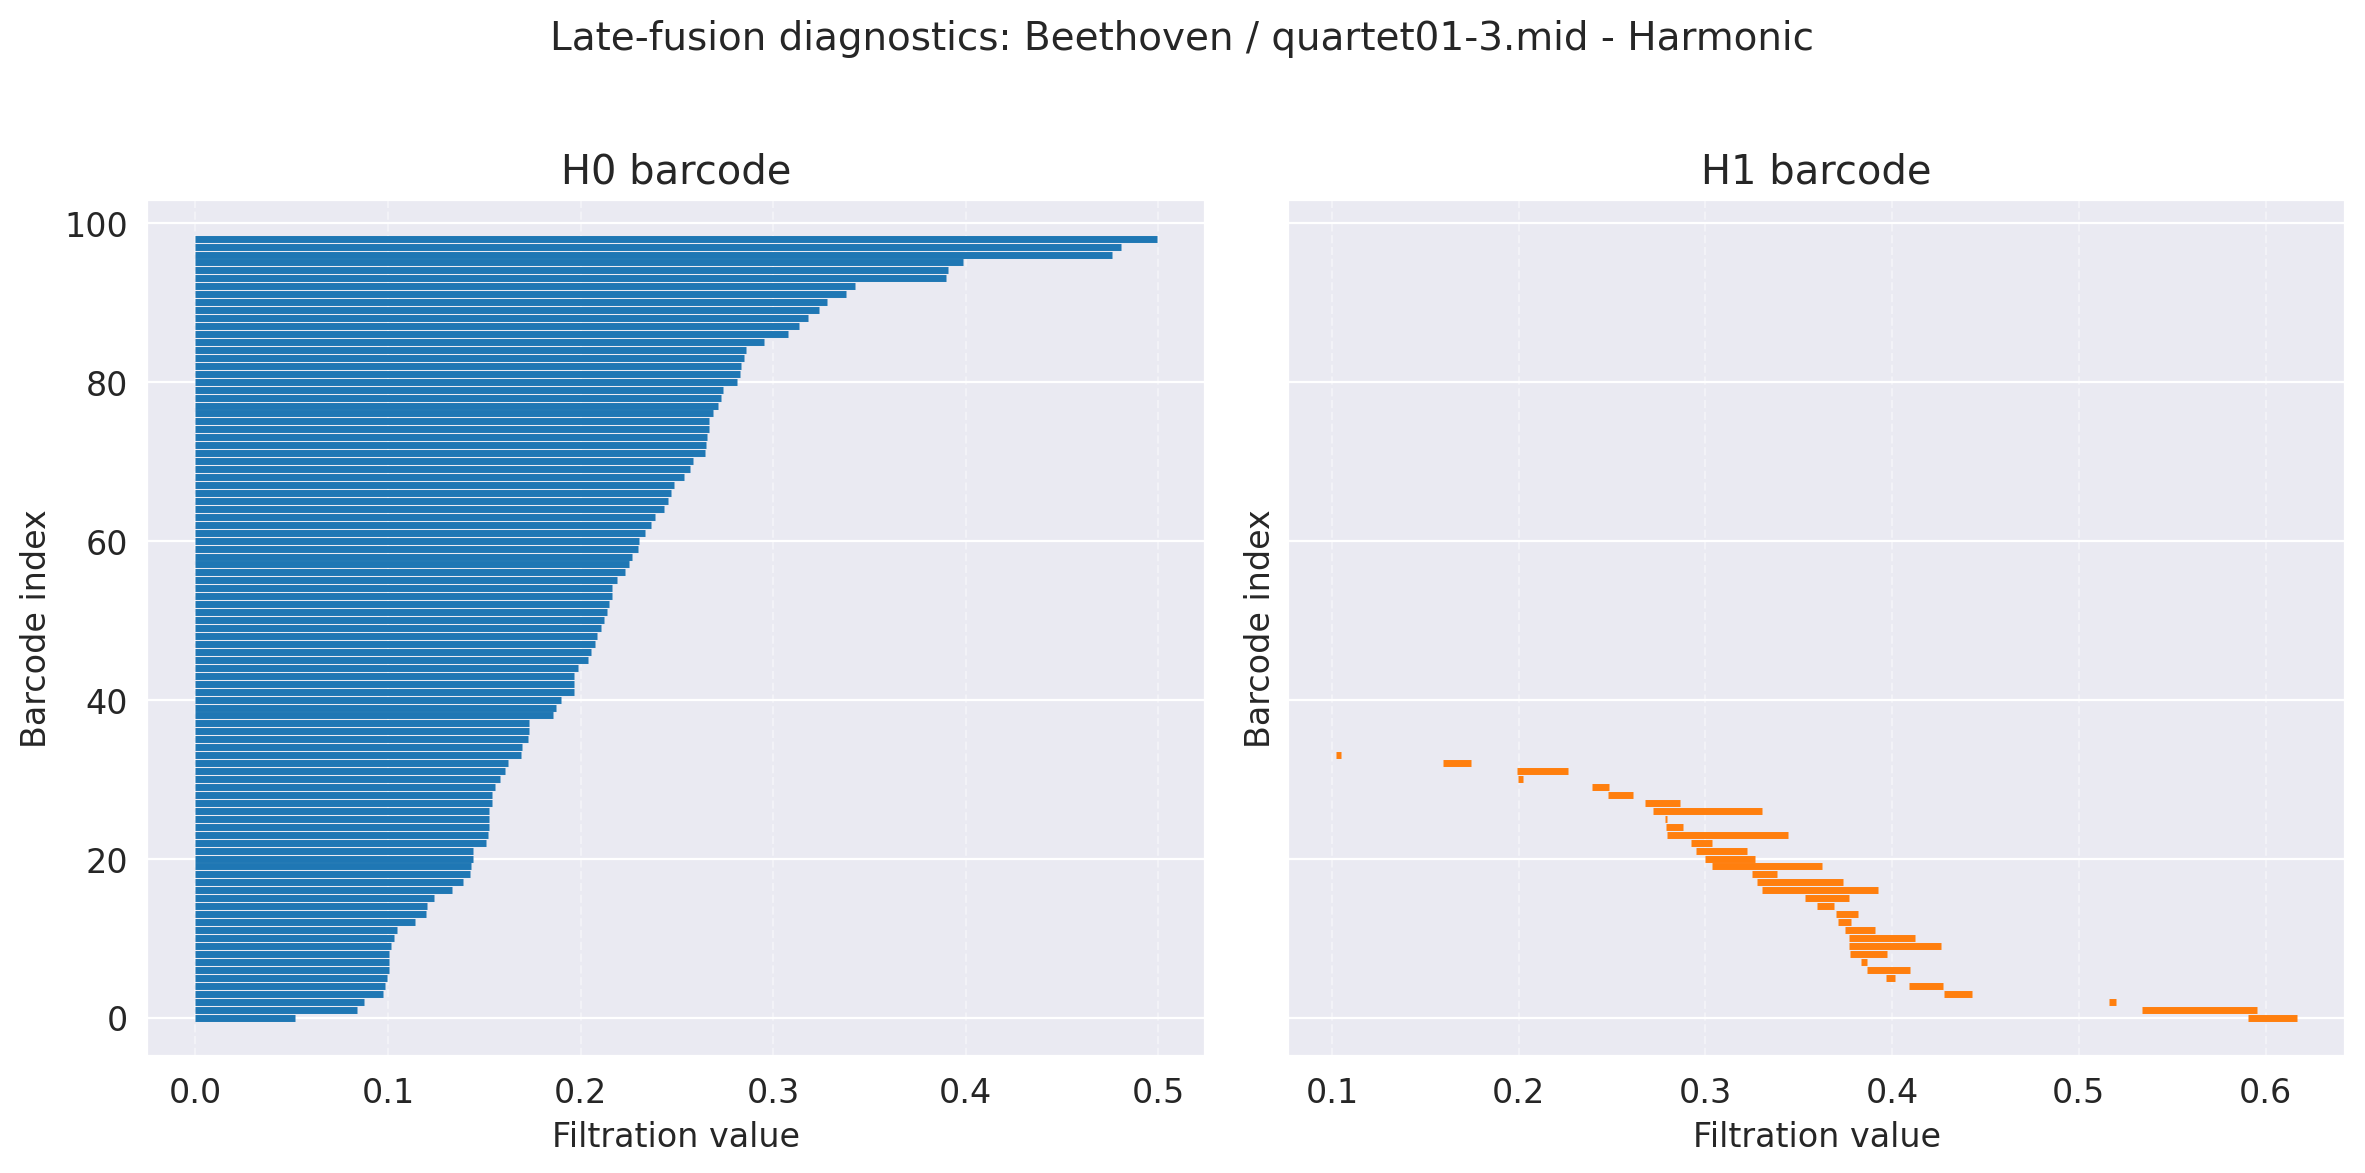

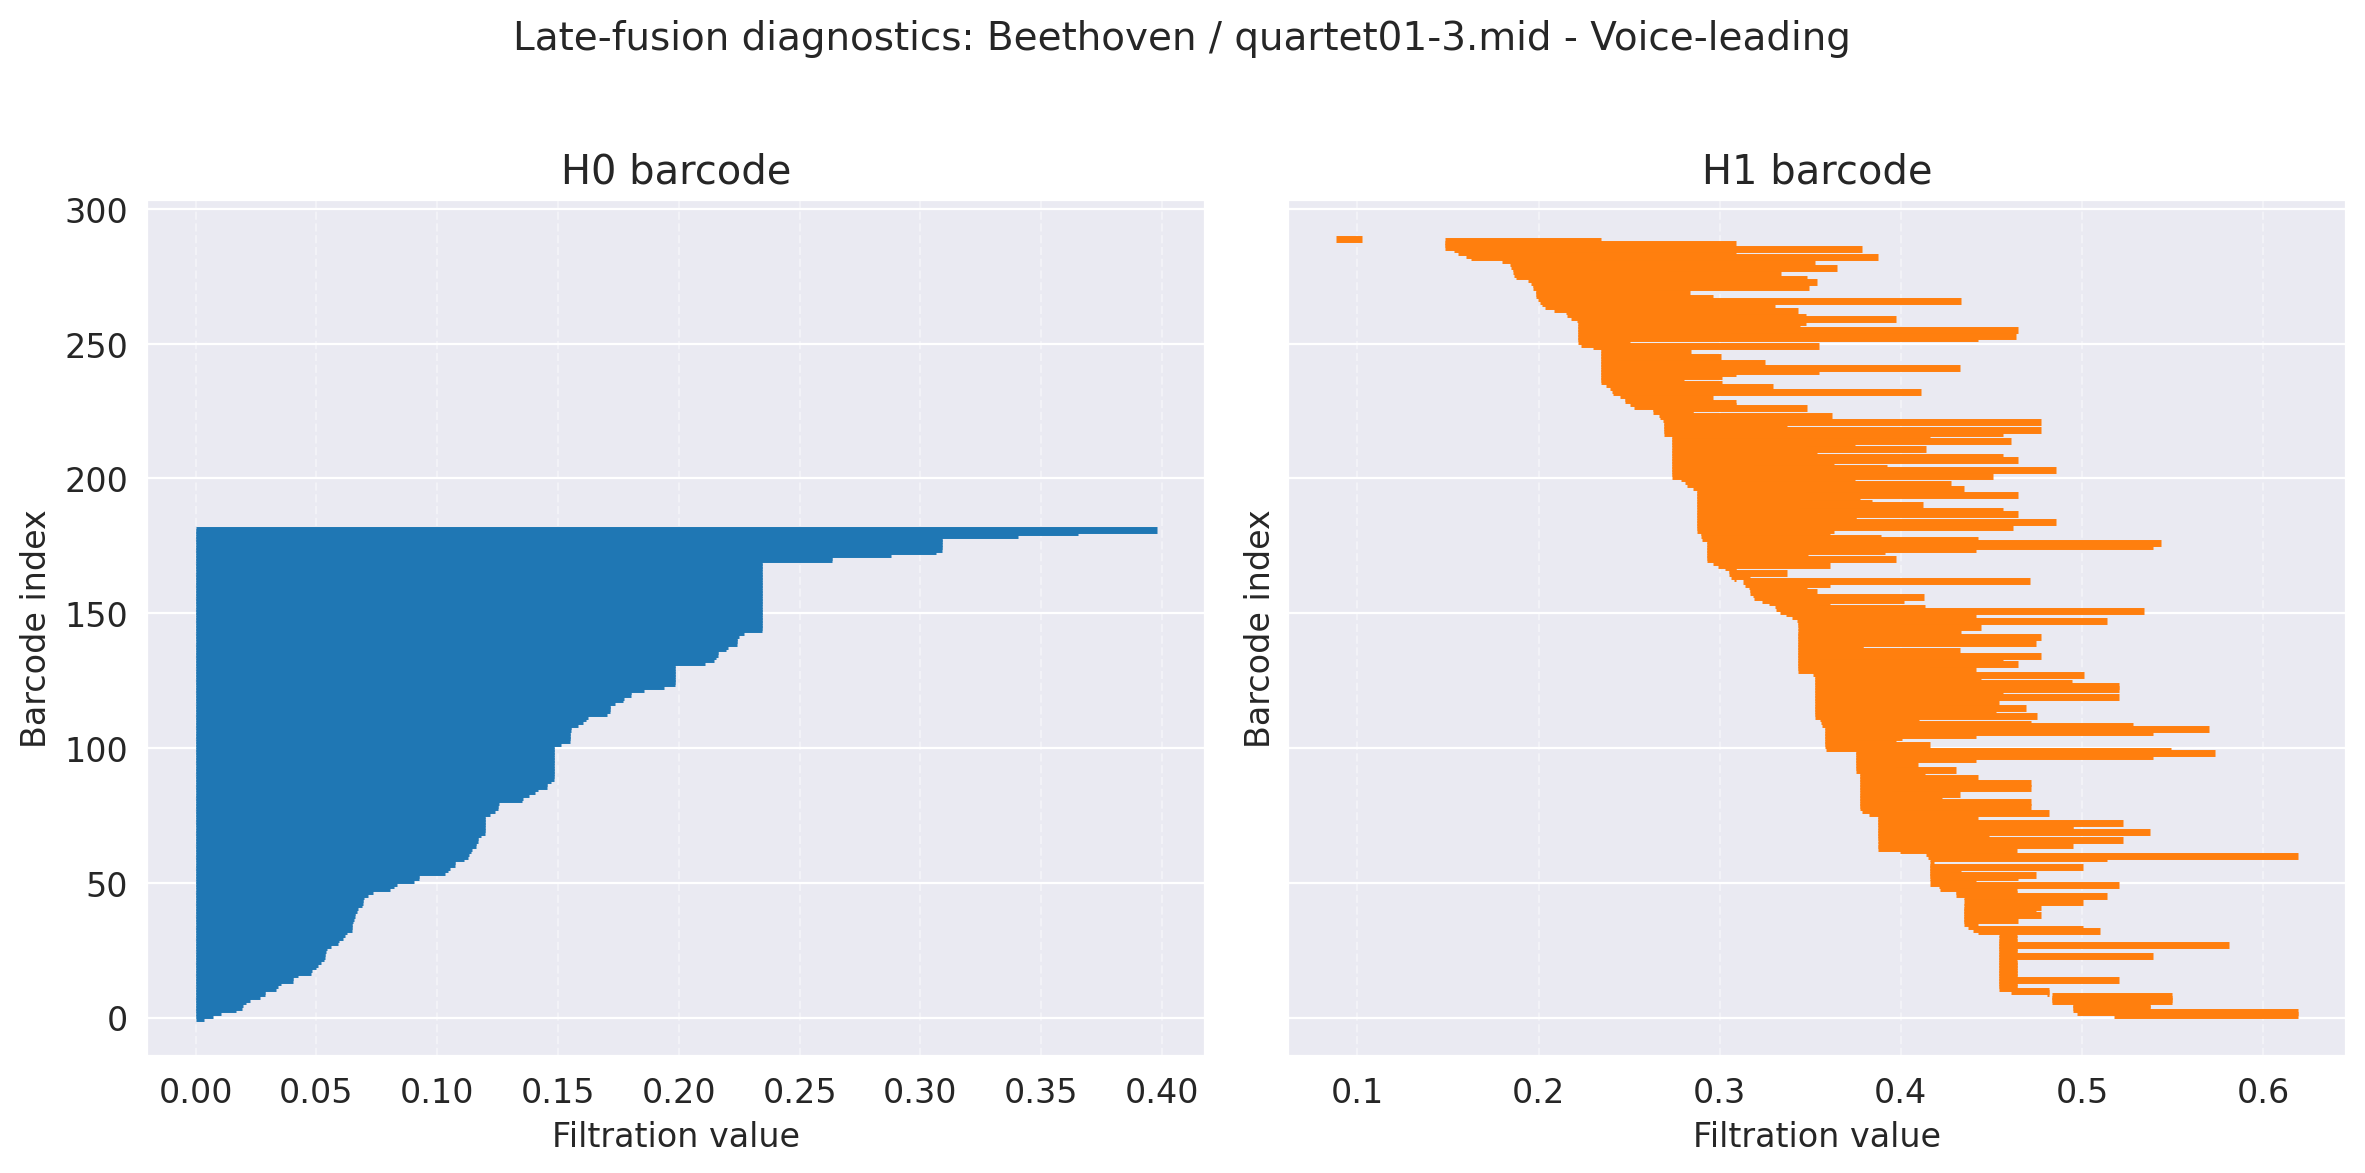

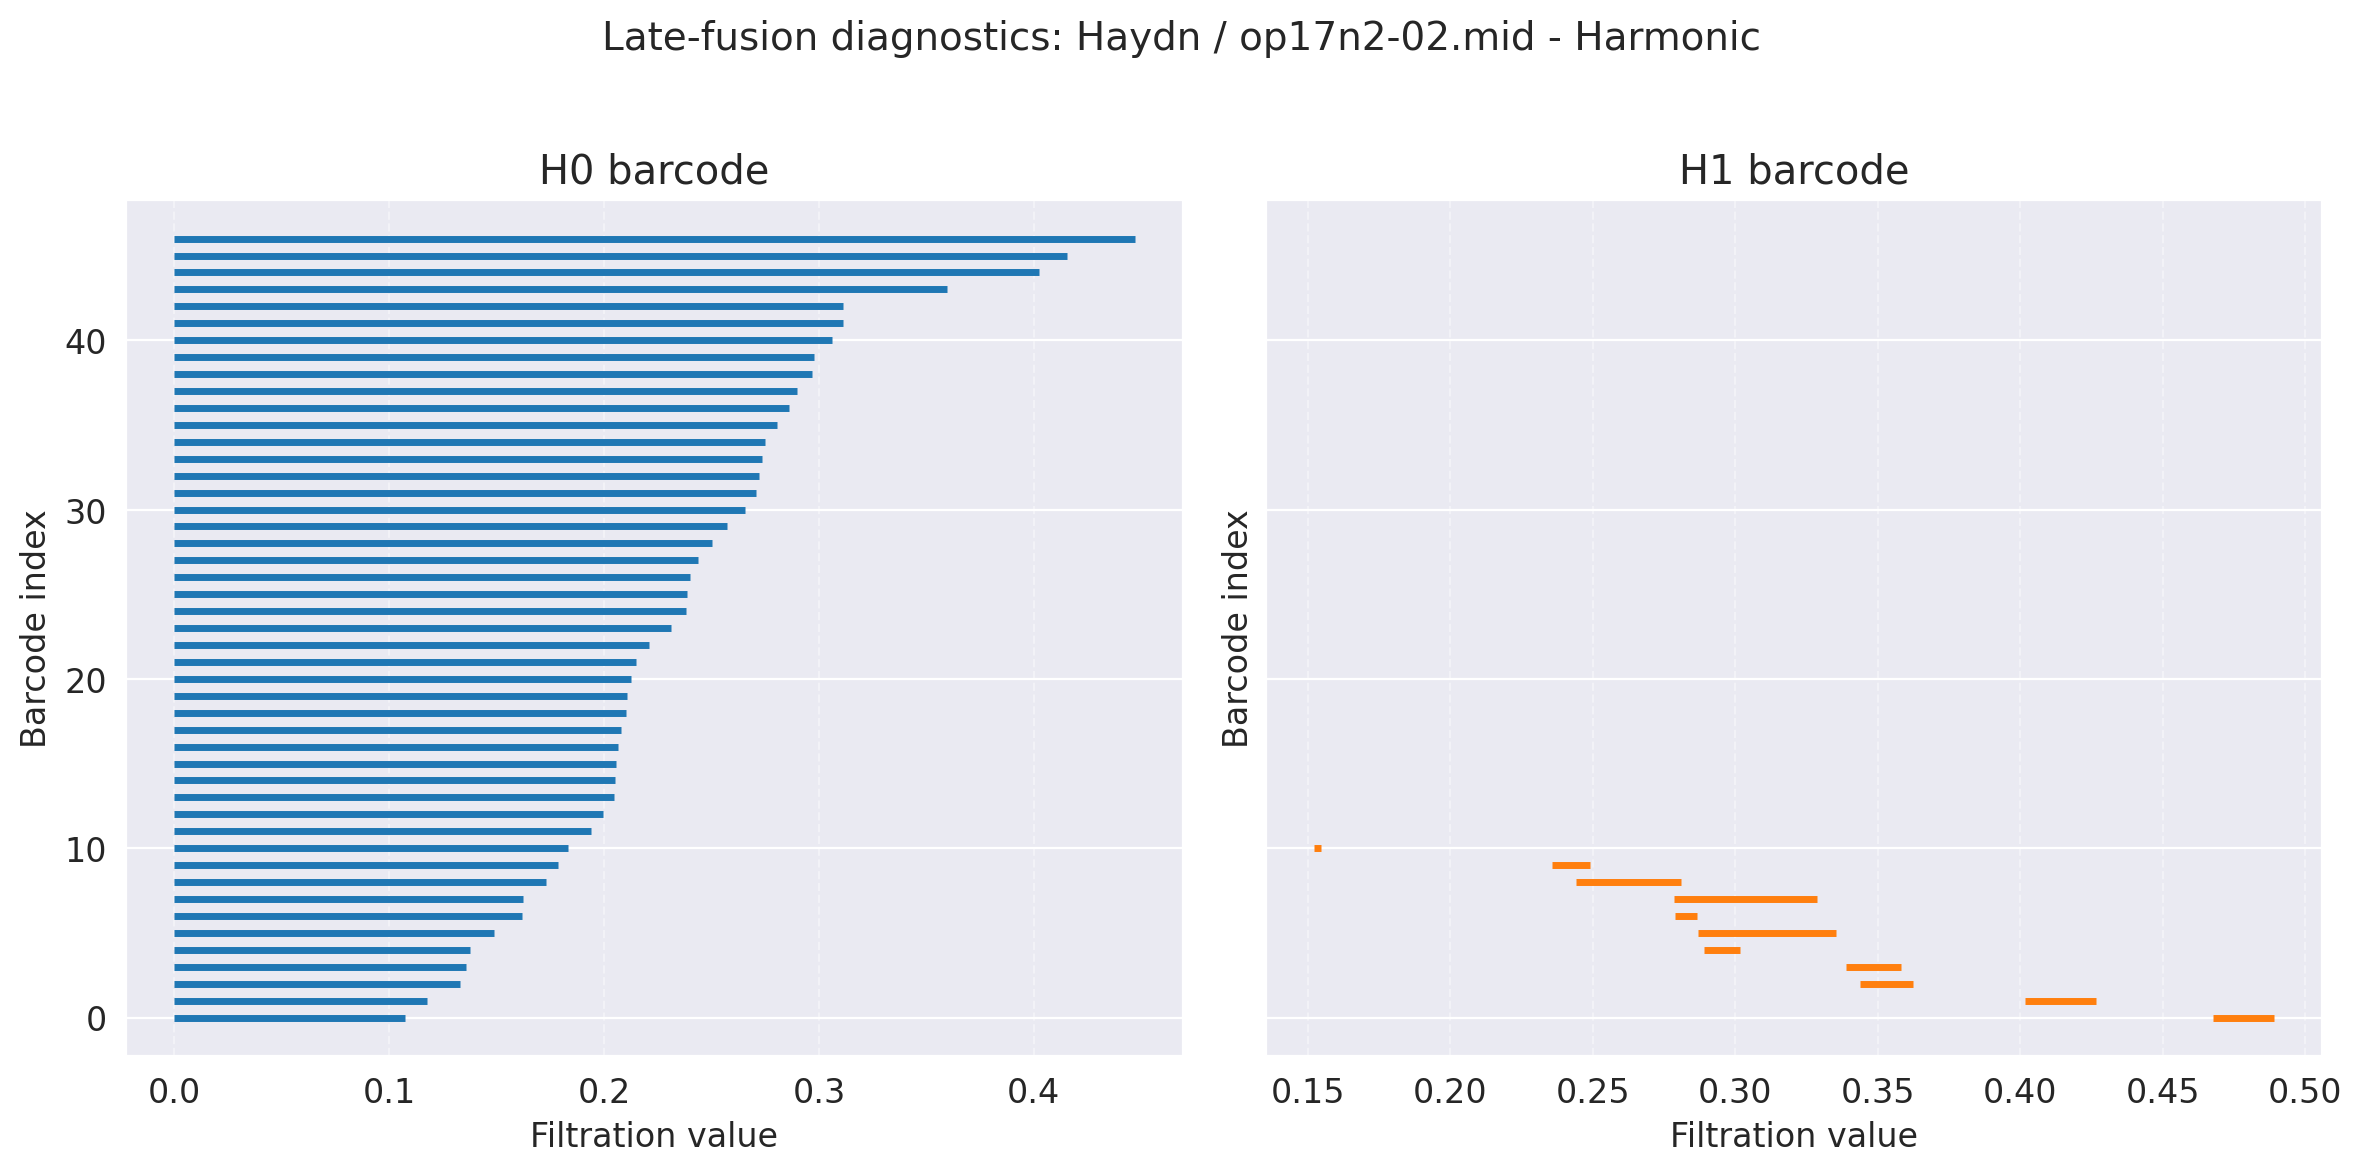

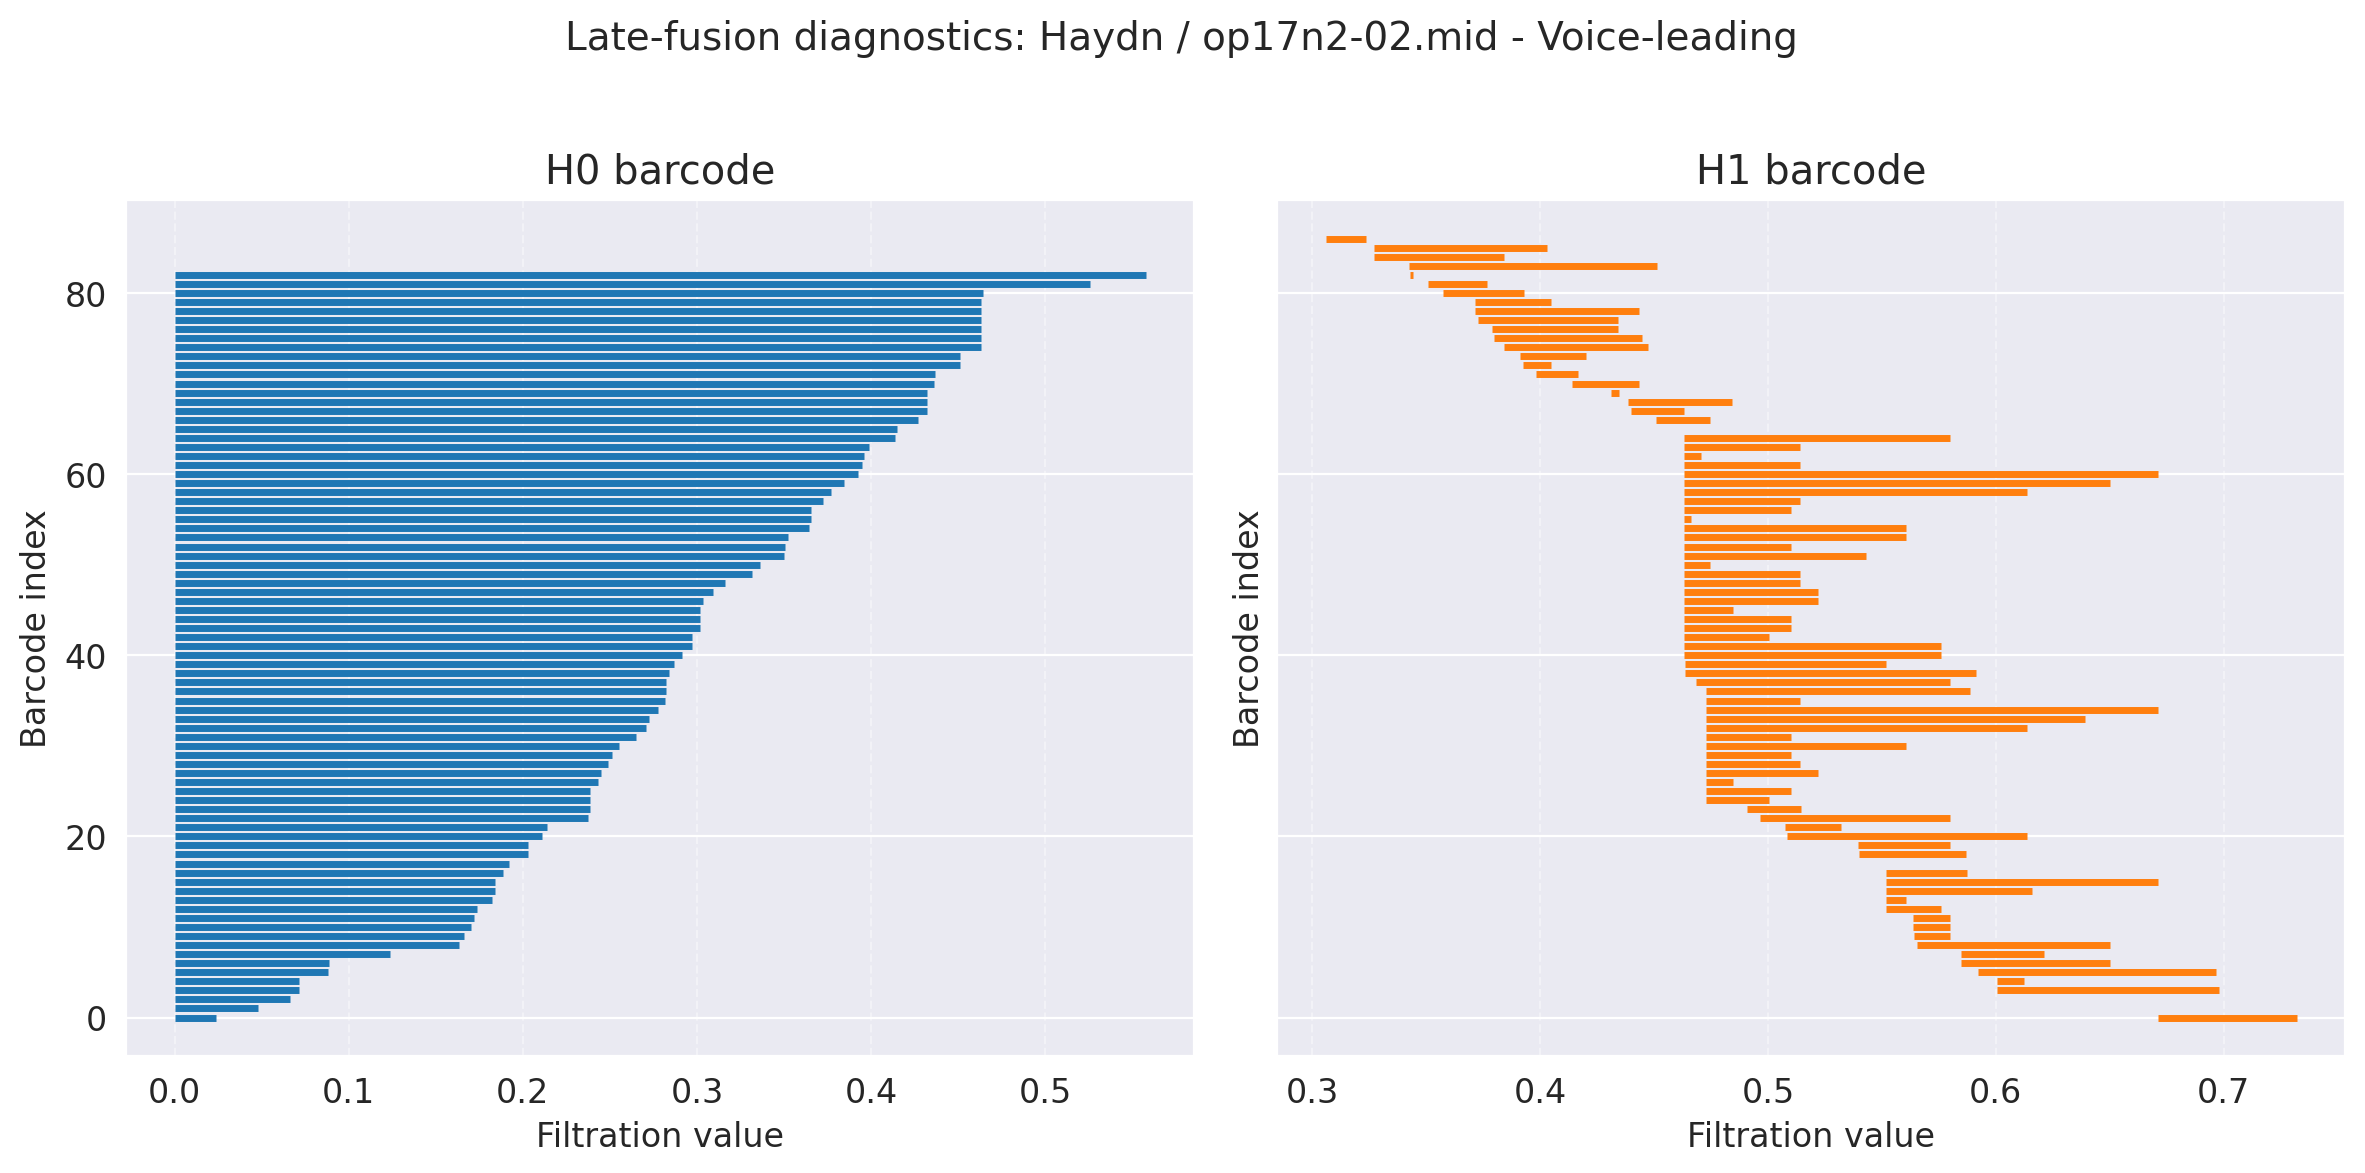

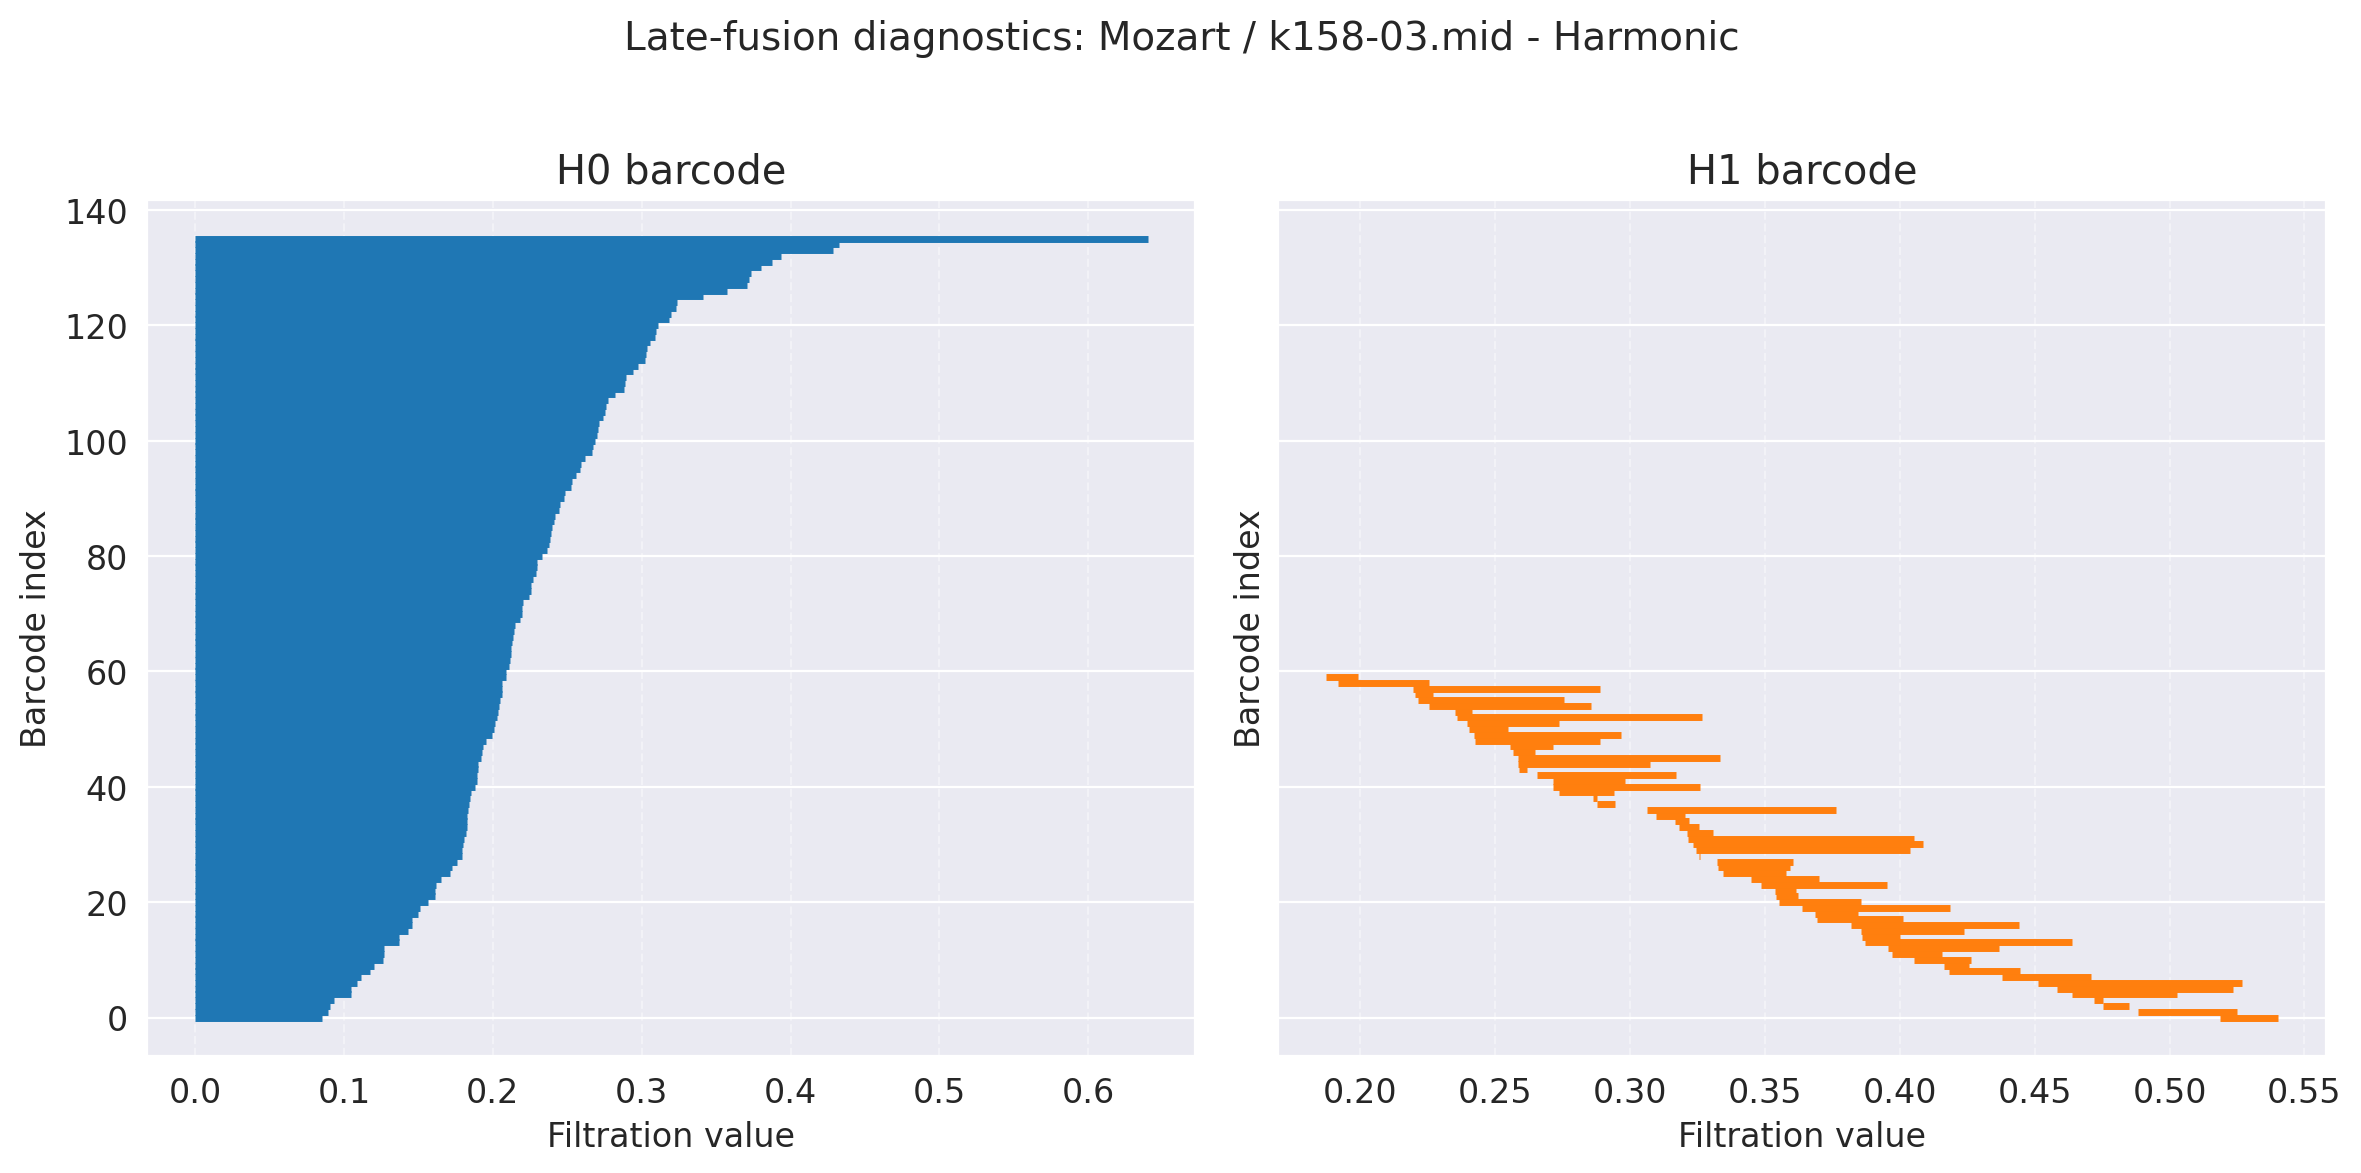

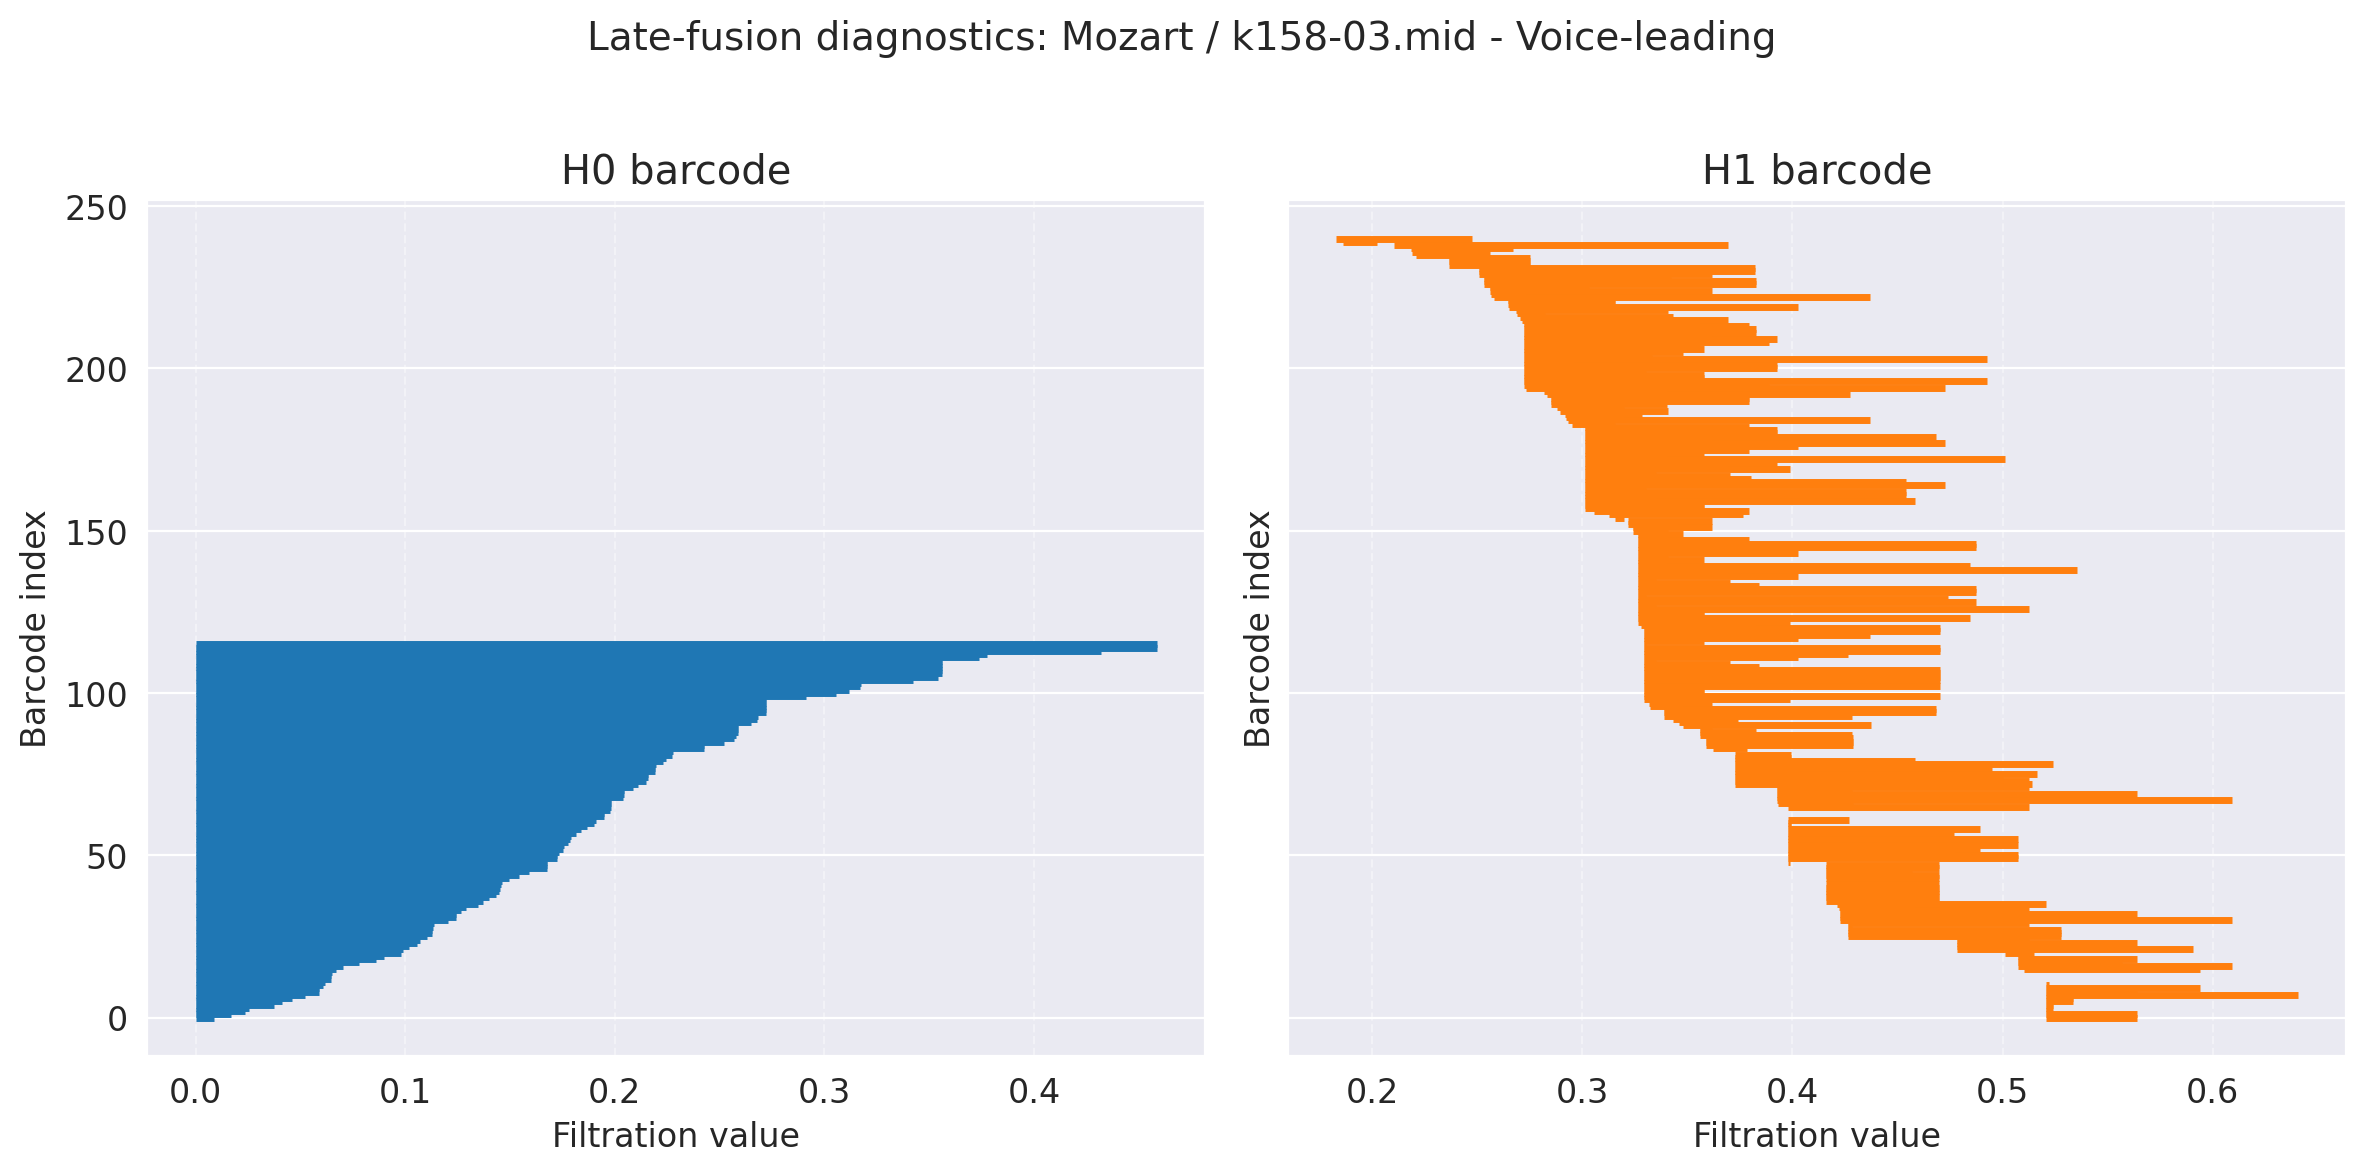

In [56]:
small_fusion_examples = (
    df_small_fusion.groupby("composer", as_index=False)
    .first()[["composer", "filename", "filepath"]]
)

display(small_fusion_examples)

for _, row in small_fusion_examples.iterrows():
    plot_fusion_barcodes_for_piece(
        row["filename"],
        row["filepath"],
        event_cache_small,
        VOICE_INTERVAL_MODULUS,
        quant_step=QUANT_STEP,
        title=f"Late-fusion diagnostics: {row['composer']} / {row['filename']}",
        voice_rest_cost=VOICE_REST_COST,
        voice_unique_only=True,
        voice_round_decimals=6,
        harm_unique_only=True,
        harm_round_decimals=8,
        maxdim=1
    )

The comparison of the three models shows that the harmonic, voice-leading, and late-fusion branches capture different aspects of stylistic organization. On the small dataset, the voice-leading-only model is the strongest overall. It has the highest explained variance in the first two principal components, \(0.9262\), the best silhouette scores, \(0.0632\) in the full space and \(0.0892\) in the PCA plane, the lowest Davies-Bouldin index, \(2.1597\), and the highest leave-one-out 1-NN accuracy, \(0.7222\). The harmonic-only model is weaker on this focused corpus, while late fusion improves over harmonic-only but does not surpass voice-leading-only.

On the large dataset, the ranking is less clear. The voice-leading-only model still has the highest explained variance, \(0.9250\), but it does not give the best classification or clustering results. The harmonic-only and late-fusion models both reach a 1-NN accuracy of \(0.5463\), while voice-leading-only gives \(0.4815\). Late fusion gives the best full-space silhouette among the three models, although it remains negative, and it also gives the highest nearest-centroid accuracy, \(0.4630\). At the same time, harmonic-only has the lowest Davies-Bouldin index, \(7.6466\), while late fusion has the largest one, \(7.9458\).

Overall, the results show that there is no single universally dominant representation. Voice-leading is the most effective model on the focused corpus, where motion between consecutive vertical events provides a clear stylistic signal. On the larger mixed-genre corpus, the three models become closer in performance, and the advantage depends on the chosen criterion. Harmonic descriptors provide a stable baseline, voice-leading gives a strong low-dimensional structure, and late fusion increases centroid separation but also increases within-class spread. Therefore, the chapter treats fusion not as a final optimal model, but as a controlled comparison showing how harmonic and motion-based topological information interact.

In [57]:
df_small_fusion.to_csv("./tables/df_small_fusion_features_ch2.csv", index=False)
df_big_fusion.to_csv("./tables/df_big_fusion_features_ch2.csv", index=False)
df_fusion_eval_summary.to_csv("./tables/fusion_eval_summary.csv", index=False)
df_small_fusion_dispersion.to_csv("./tables/fusion_small_dispersion.csv", index=False)
df_big_fusion_dispersion.to_csv("./tables/fusion_big_dispersion.csv", index=False)
df_small_fusion_centroids.to_csv("./tables/fusion_small_centroid_distances.csv")
df_big_fusion_centroids.to_csv("./tables/fusion_big_centroid_distances.csv")
df_small_fusion_pca_disp.to_csv("./tables/fusion_small_pca_dispersion.csv", index=False)
df_big_fusion_pca_disp.to_csv("./tables/fusion_big_pca_dispersion.csv", index=False)
df_small_model_comparison.to_csv("./tables/small_model_comparison.csv", index=False)
df_big_model_comparison.to_csv("./tables/big_model_comparison.csv", index=False)

print("Saved:")
print("./tables/df_small_fusion_features_ch2.csv")
print("./tables/df_big_fusion_features_ch2.csv")
print("./tables/fusion_eval_summary.csv")
print("./tables/fusion_small_dispersion.csv")
print("./tables/fusion_big_dispersion.csv")
print("./tables/fusion_small_centroid_distances.csv")
print("./tables/fusion_big_centroid_distances.csv")
print("./tables/fusion_small_pca_dispersion.csv")
print("./tables/fusion_big_pca_dispersion.csv")
print("./tables/small_model_comparison.csv")
print("./tables/big_model_comparison.csv")

Saved:
./tables/df_small_fusion_features_ch2.csv
./tables/df_big_fusion_features_ch2.csv
./tables/fusion_eval_summary.csv
./tables/fusion_small_dispersion.csv
./tables/fusion_big_dispersion.csv
./tables/fusion_small_centroid_distances.csv
./tables/fusion_big_centroid_distances.csv
./tables/fusion_small_pca_dispersion.csv
./tables/fusion_big_pca_dispersion.csv
./tables/small_model_comparison.csv
./tables/big_model_comparison.csv
